In [1]:
!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless opencv-contrib-python-headless
!pip install opencv-python==4.10.0.84

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 17.9 MB/s eta 0:00:00


In [2]:
import cv2

print("OpenCV version:", cv2.__version__)
print("CascadeClassifier available:",
      hasattr(cv2, "CascadeClassifier"))

OpenCV version: 4.10.0
CascadeClassifier available: True


OpenCV version: 4.10.0

Upload a face image:


Saving group.jpg to group (1).jpg
Image uploaded successfully: group (1).jpg
Haar Cascade loaded successfully.


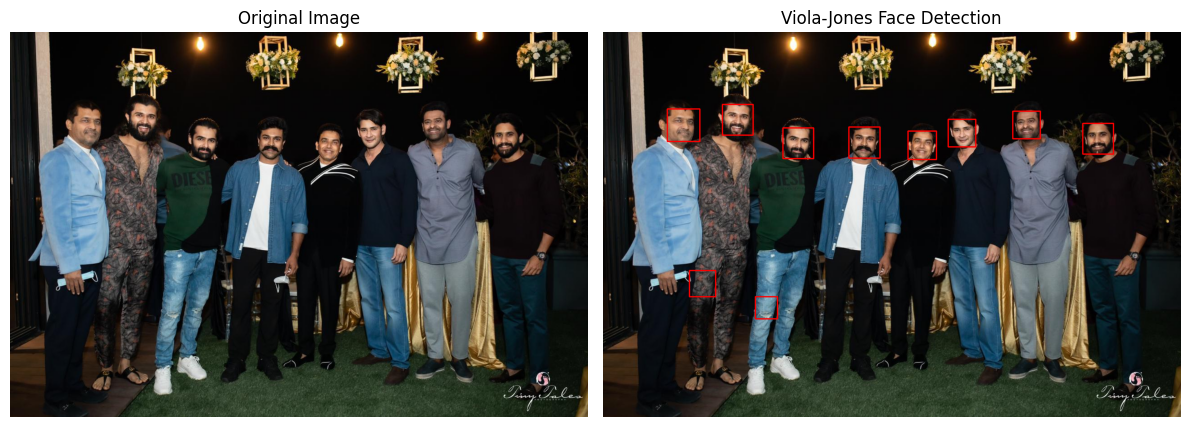


========== VIOLA-JONES RESULT ==========
Detected faces: 10

Enter the actual number of faces
present in the image.
Ground-truth number of faces: 8

Based on the displayed detection result:
True Positives (TP): 8
False Positives (FP): 2
False Negatives (FN): 2

========== PERFORMANCE METRICS ==========
True Positives (TP): 8
False Positives (FP): 2
False Negatives (FN): 2

Precision: 0.8000
Recall: 0.8000
F1-Score: 0.8000

========== PERCENTAGE ==========
Precision: 80.00%
Recall: 80.00%
F1-Score: 80.00%


In [4]:
# ==========================================================
# CO4 - AT1 - TASK 1
# Viola-Jones Face Detection
# Precision, Recall and F1-Score
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ----------------------------------------------------------
# STEP 1: Check OpenCV
# ----------------------------------------------------------

print("OpenCV version:", cv2.__version__)

if not hasattr(cv2, "CascadeClassifier"):
    raise RuntimeError(
        "CascadeClassifier is unavailable. "
        "Restart the Colab runtime after installing "
        "OpenCV 4.10.0.84."
    )

# ----------------------------------------------------------
# STEP 2: Upload Image
# ----------------------------------------------------------

print("\nUpload a face image:")

uploaded = files.upload()

filename = next(iter(uploaded))

print("Image uploaded successfully:", filename)

# ----------------------------------------------------------
# STEP 3: Read Image
# ----------------------------------------------------------

image = cv2.imread(filename)

if image is None:
    raise ValueError("Unable to read the uploaded image.")

# Convert BGR → RGB
rgb_image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

# Convert to grayscale
gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

# ----------------------------------------------------------
# STEP 4: Load Viola-Jones Haar Cascade
# ----------------------------------------------------------

cascade_file = (
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

face_cascade = cv2.CascadeClassifier(
    cascade_file
)

# Verify cascade
if face_cascade.empty():
    raise RuntimeError(
        "Haar Cascade could not be loaded."
    )

print("Haar Cascade loaded successfully.")

# ----------------------------------------------------------
# STEP 5: Detect Faces
# ----------------------------------------------------------

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

# ----------------------------------------------------------
# STEP 6: Draw Detected Faces
# ----------------------------------------------------------

result = rgb_image.copy()

for (x, y, w, h) in faces:

    cv2.rectangle(
        result,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        2
    )

# ----------------------------------------------------------
# STEP 7: Display Results
# ----------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title("Viola-Jones Face Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# STEP 8: Display Detected Face Count
# ----------------------------------------------------------

detected_faces = len(faces)

print("\n========== VIOLA-JONES RESULT ==========")

print("Detected faces:", detected_faces)

# ----------------------------------------------------------
# STEP 9: Enter Ground-Truth Information
# ----------------------------------------------------------

print("\nEnter the actual number of faces")
print("present in the image.")

ground_truth = int(
    input("Ground-truth number of faces: ")
)

# ----------------------------------------------------------
# STEP 10: Enter TP, FP and FN
# ----------------------------------------------------------

print("\nBased on the displayed detection result:")

TP = int(
    input("True Positives (TP): ")
)

FP = int(
    input("False Positives (FP): ")
)

FN = int(
    input("False Negatives (FN): ")
)

# ----------------------------------------------------------
# STEP 11: Calculate Precision
# ----------------------------------------------------------

if TP + FP != 0:
    precision = TP / (TP + FP)
else:
    precision = 0.0

# ----------------------------------------------------------
# STEP 12: Calculate Recall
# ----------------------------------------------------------

if TP + FN != 0:
    recall = TP / (TP + FN)
else:
    recall = 0.0

# ----------------------------------------------------------
# STEP 13: Calculate F1-Score
# ----------------------------------------------------------

if precision + recall != 0:
    f1 = (
        2 * precision * recall
        / (precision + recall)
    )
else:
    f1 = 0.0

# ----------------------------------------------------------
# STEP 14: Display Metrics
# ----------------------------------------------------------

print("\n========== PERFORMANCE METRICS ==========")

print("True Positives (TP):", TP)
print("False Positives (FP):", FP)
print("False Negatives (FN):", FN)

print(
    "\nPrecision:",
    f"{precision:.4f}"
)

print(
    "Recall:",
    f"{recall:.4f}"
)

print(
    "F1-Score:",
    f"{f1:.4f}"
)

print("\n========== PERCENTAGE ==========")

print(
    "Precision:",
    f"{precision * 100:.2f}%"
)

print(
    "Recall:",
    f"{recall * 100:.2f}%"
)

print(
    "F1-Score:",
    f"{f1 * 100:.2f}%"
)

In [9]:
!pip install -q ultralytics

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Upload an image containing objects:


Saving images.jpg to images.jpg
Image uploaded successfully: images.jpg
YOLO model loaded successfully.

========== YOLO DETECTIONS ==========
Detection 1: Class=person, Confidence=0.8950
Detection 2: Class=chair, Confidence=0.8330
Detection 3: Class=car, Confidence=0.7610
Detection 4: Class=person, Confidence=0.7406
Detection 5: Class=person, Confidence=0.5657
Detection 6: Class=person, Confidence=0.4215
Detection 7: Class=chair, Confidence=0.4016
Detection 8: Class=person, Confidence=0.3869
Detection 9: Class=car, Confidence=0.3248
Detection 10: Class=potted plant, Confidence=0.2022
Detection 11: Class=potted plant, Confidence=0.1816
Detection 12: Class=potted plant, Confidence=0.1785
Detection 13: Class=person, Confidence=0.1483
Detection 14: Class=person, Confidence=0.1367
Detection 15: Class=potted plant, Confidence=0.1171
Detection 16: Class=car, Confidence=0.1126

========== AFTER NMS ==========
Kept detection: Class=person, Confidence=0.8950
Kept detection: Class=chair, Confide

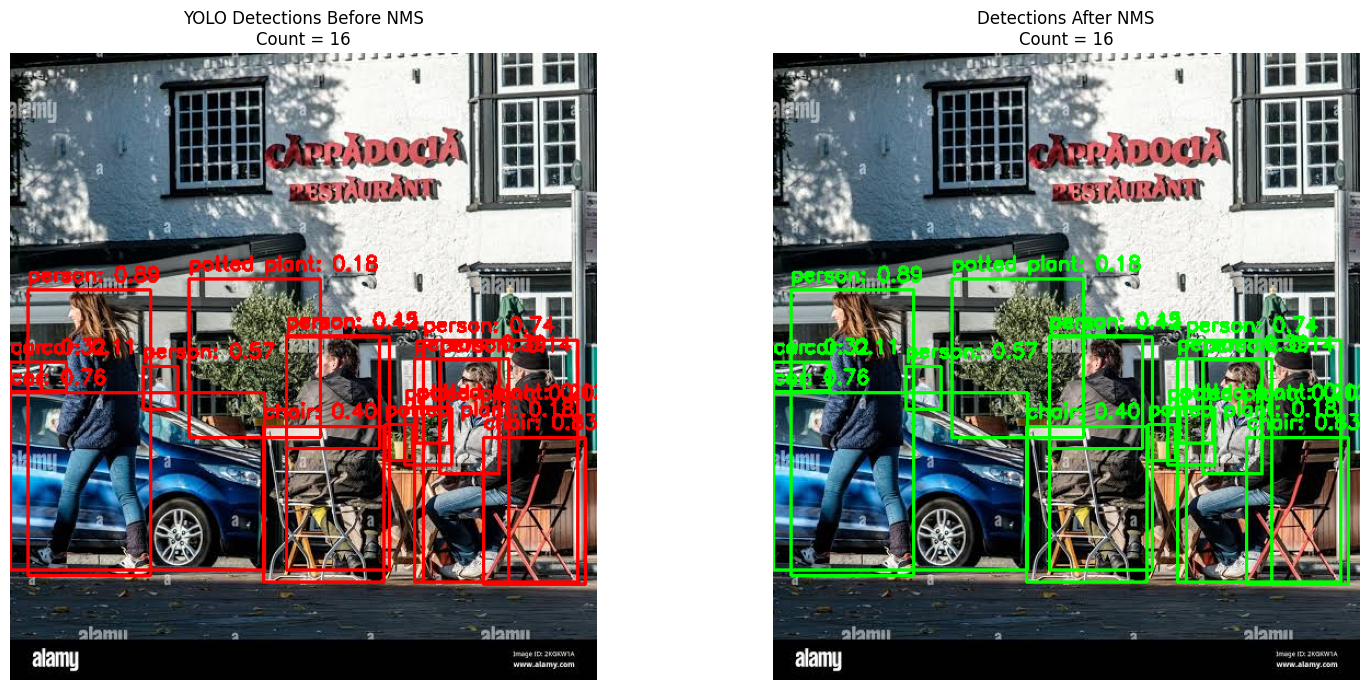


========== NMS SUMMARY ==========
Detections before NMS: 16
Detections after NMS: 16
Detections removed by NMS: 0
Confidence threshold: 0.1
NMS IoU threshold: 0.5


In [10]:
# ==========================================================
# CO4 - AT1 - TASK 2
# YOLO Confidence Scores and Non-Maximum Suppression (NMS)
# ==========================================================

from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ----------------------------------------------------------
# STEP 1: Upload Image
# ----------------------------------------------------------

print("Upload an image containing objects:")

uploaded = files.upload()

filename = next(iter(uploaded))

print("Image uploaded successfully:", filename)

# ----------------------------------------------------------
# STEP 2: Load YOLO Model
# ----------------------------------------------------------

model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully.")

# ----------------------------------------------------------
# STEP 3: Run YOLO Detection
# ----------------------------------------------------------

results = model.predict(
    source=filename,
    conf=0.10,
    iou=0.50,
    verbose=False
)

result = results[0]

# ----------------------------------------------------------
# STEP 4: Read Original Image
# ----------------------------------------------------------

image = cv2.imread(filename)

if image is None:
    raise ValueError("Unable to read the uploaded image.")

rgb_image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

# ----------------------------------------------------------
# STEP 5: Extract Detection Information
# ----------------------------------------------------------

boxes = result.boxes

if boxes is None or len(boxes) == 0:

    print("No objects were detected.")

else:

    xyxy = boxes.xyxy.cpu().numpy()
    confidence = boxes.conf.cpu().numpy()
    class_ids = boxes.cls.cpu().numpy().astype(int)

    # ------------------------------------------------------
    # STEP 6: Display Raw YOLO Detections
    # ------------------------------------------------------

    raw_image = rgb_image.copy()

    print("\n========== YOLO DETECTIONS ==========")

    for i in range(len(xyxy)):

        x1, y1, x2, y2 = xyxy[i].astype(int)

        conf = confidence[i]

        class_id = class_ids[i]

        class_name = model.names[class_id]

        cv2.rectangle(
            raw_image,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )

        label = (
            f"{class_name}: "
            f"{conf:.2f}"
        )

        cv2.putText(
            raw_image,
            label,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

        print(
            f"Detection {i + 1}: "
            f"Class={class_name}, "
            f"Confidence={conf:.4f}"
        )

    # ------------------------------------------------------
    # STEP 7: Apply NMS Manually
    # ------------------------------------------------------

    # Convert boxes to [x, y, width, height]
    nms_boxes = []

    for box in xyxy:

        x1, y1, x2, y2 = box

        nms_boxes.append([
            float(x1),
            float(y1),
            float(x2 - x1),
            float(y2 - y1)
        ])

    nms_boxes = np.array(
        nms_boxes,
        dtype=np.float32
    )

    scores = confidence.astype(
        np.float32
    )

    # Apply NMS
    nms_threshold = 0.50

    indices = cv2.dnn.NMSBoxes(
        nms_boxes.tolist(),
        scores.tolist(),
        score_threshold=0.10,
        nms_threshold=nms_threshold
    )

    # Convert result to a simple list
    if len(indices) > 0:

        kept_indices = np.array(
            indices
        ).flatten()

    else:

        kept_indices = np.array(
            [],
            dtype=int
        )

    # ------------------------------------------------------
    # STEP 8: Draw NMS Result
    # ------------------------------------------------------

    nms_image = rgb_image.copy()

    print("\n========== AFTER NMS ==========")

    for index in kept_indices:

        x1, y1, x2, y2 = (
            xyxy[index].astype(int)
        )

        conf = confidence[index]

        class_id = class_ids[index]

        class_name = model.names[class_id]

        cv2.rectangle(
            nms_image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        label = (
            f"{class_name}: "
            f"{conf:.2f}"
        )

        cv2.putText(
            nms_image,
            label,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

        print(
            f"Kept detection: "
            f"Class={class_name}, "
            f"Confidence={conf:.4f}"
        )

    # ------------------------------------------------------
    # STEP 9: Display Before and After NMS
    # ------------------------------------------------------

    plt.figure(figsize=(16, 7))

    plt.subplot(1, 2, 1)
    plt.imshow(raw_image)
    plt.title(
        f"YOLO Detections Before NMS\n"
        f"Count = {len(xyxy)}"
    )
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(nms_image)
    plt.title(
        f"Detections After NMS\n"
        f"Count = {len(kept_indices)}"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------
    # STEP 10: Display Numerical Summary
    # ------------------------------------------------------

    print("\n========== NMS SUMMARY ==========")

    print(
        "Detections before NMS:",
        len(xyxy)
    )

    print(
        "Detections after NMS:",
        len(kept_indices)
    )

    print(
        "Detections removed by NMS:",
        len(xyxy) - len(kept_indices)
    )

    print(
        "Confidence threshold:",
        0.10
    )

    print(
        "NMS IoU threshold:",
        nms_threshold
    )

Upload an image containing one or more faces:


Saving group.jpg to group (2).jpg
Image uploaded successfully: group (2).jpg


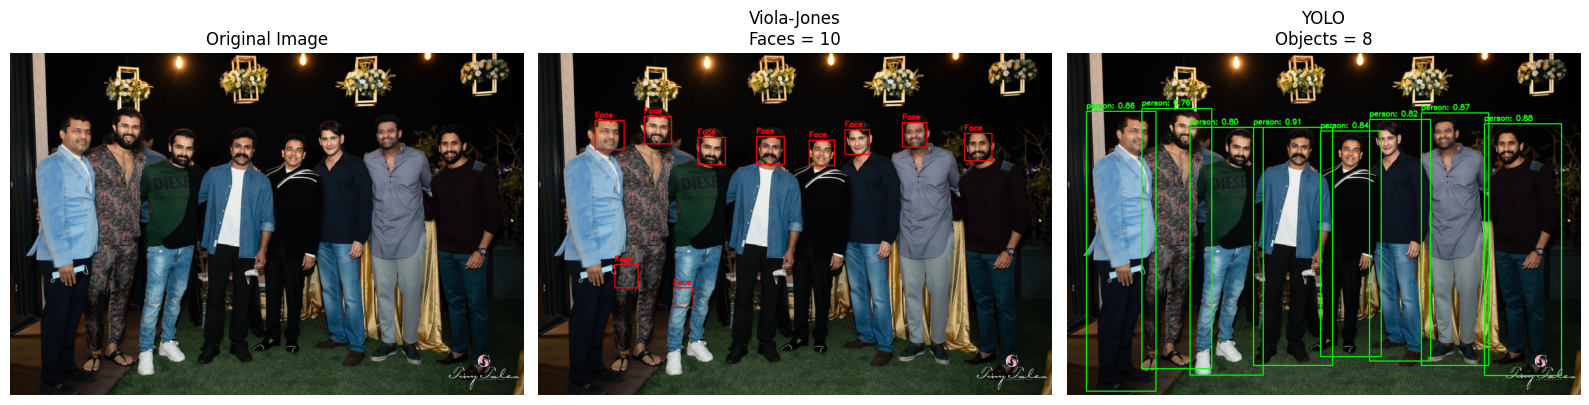


========== COMPARATIVE ANALYSIS ==========

VIOLA-JONES
-----------------------------
Detected faces: 10
Processing time: 1.2455 seconds

YOLO
-----------------------------
Detected objects: 8
Processing time: 0.3266 seconds

YOLO Confidence Scores:
1. person = 0.9087
2. person = 0.8791
3. person = 0.8733
4. person = 0.8574
5. person = 0.8354
6. person = 0.8164
7. person = 0.8047
8. person = 0.7572

========== COMPARISON TABLE ==========
Method         Detections     Time (s)       
---------------------------------------------
Viola-Jones    10             1.2455         
YOLO           8              0.3266         

Comparative analysis completed successfully.


In [11]:
# ==========================================================
# CO4 - AT1 - TASK 3
# Comparative Analysis of Viola-Jones and YOLO
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

from google.colab import files
from ultralytics import YOLO

# ----------------------------------------------------------
# STEP 1: Upload Image
# ----------------------------------------------------------

print("Upload an image containing one or more faces:")

uploaded = files.upload()

filename = next(iter(uploaded))

print("Image uploaded successfully:", filename)

# ----------------------------------------------------------
# STEP 2: Read Image
# ----------------------------------------------------------

image = cv2.imread(filename)

if image is None:
    raise ValueError("Unable to read the uploaded image.")

rgb_image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

# ==========================================================
# PART A - VIOLA-JONES
# ==========================================================

# ----------------------------------------------------------
# STEP 3: Load Haar Cascade
# ----------------------------------------------------------

cascade_file = (
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

face_cascade = cv2.CascadeClassifier(
    cascade_file
)

if face_cascade.empty():
    raise RuntimeError(
        "Haar Cascade could not be loaded."
    )

# ----------------------------------------------------------
# STEP 4: Run Viola-Jones and Measure Time
# ----------------------------------------------------------

start_time = time.perf_counter()

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

viola_time = (
    time.perf_counter() - start_time
)

# ----------------------------------------------------------
# STEP 5: Draw Viola-Jones Results
# ----------------------------------------------------------

viola_result = rgb_image.copy()

for (x, y, w, h) in faces:

    cv2.rectangle(
        viola_result,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        2
    )

    cv2.putText(
        viola_result,
        "Face",
        (x, max(y - 8, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

# ==========================================================
# PART B - YOLO
# ==========================================================

# ----------------------------------------------------------
# STEP 6: Load YOLO Model
# ----------------------------------------------------------

model = YOLO("yolo11n.pt")

# ----------------------------------------------------------
# STEP 7: Run YOLO
# ----------------------------------------------------------

start_time = time.perf_counter()

yolo_results = model.predict(
    source=filename,
    conf=0.25,
    iou=0.50,
    verbose=False
)

yolo_time = (
    time.perf_counter() - start_time
)

result = yolo_results[0]

# ----------------------------------------------------------
# STEP 8: Extract YOLO Detections
# ----------------------------------------------------------

boxes = result.boxes

yolo_result = rgb_image.copy()

yolo_detections = []

if boxes is not None and len(boxes) > 0:

    xyxy = boxes.xyxy.cpu().numpy()
    confidence = boxes.conf.cpu().numpy()
    class_ids = boxes.cls.cpu().numpy().astype(int)

    for i in range(len(xyxy)):

        x1, y1, x2, y2 = (
            xyxy[i].astype(int)
        )

        conf = confidence[i]

        class_id = class_ids[i]

        class_name = model.names[class_id]

        yolo_detections.append({
            "class": class_name,
            "confidence": float(conf)
        })

        cv2.rectangle(
            yolo_result,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        label = (
            f"{class_name}: "
            f"{conf:.2f}"
        )

        cv2.putText(
            yolo_result,
            label,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

# ==========================================================
# STEP 9: Display Results
# ==========================================================

plt.figure(figsize=(16, 7))

plt.subplot(1, 3, 1)

plt.imshow(rgb_image)

plt.title("Original Image")

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(viola_result)

plt.title(
    f"Viola-Jones\n"
    f"Faces = {len(faces)}"
)

plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(yolo_result)

plt.title(
    f"YOLO\n"
    f"Objects = {len(yolo_detections)}"
)

plt.axis("off")

plt.tight_layout()
plt.show()

# ==========================================================
# STEP 10: Display Comparison
# ==========================================================

print("\n========== COMPARATIVE ANALYSIS ==========")

print("\nVIOLA-JONES")
print("-----------------------------")
print(
    "Detected faces:",
    len(faces)
)
print(
    "Processing time:",
    f"{viola_time:.4f} seconds"
)

print("\nYOLO")
print("-----------------------------")
print(
    "Detected objects:",
    len(yolo_detections)
)
print(
    "Processing time:",
    f"{yolo_time:.4f} seconds"
)

# ----------------------------------------------------------
# YOLO Confidence Scores
# ----------------------------------------------------------

if len(yolo_detections) > 0:

    print("\nYOLO Confidence Scores:")

    for i, detection in enumerate(
        yolo_detections,
        start=1
    ):

        print(
            f"{i}. "
            f"{detection['class']} = "
            f"{detection['confidence']:.4f}"
        )

# ==========================================================
# STEP 11: Create Comparison Table
# ==========================================================

print("\n========== COMPARISON TABLE ==========")

print(
    f"{'Method':<15}"
    f"{'Detections':<15}"
    f"{'Time (s)':<15}"
)

print("-" * 45)

print(
    f"{'Viola-Jones':<15}"
    f"{len(faces):<15}"
    f"{viola_time:<15.4f}"
)

print(
    f"{'YOLO':<15}"
    f"{len(yolo_detections):<15}"
    f"{yolo_time:<15.4f}"
)

print(
    "\nComparative analysis completed successfully."
)

Upload an image:


Saving group.jpg to group (4).jpg
Image uploaded successfully: group (4).jpg

Image dimensions:
Width : 1280
Height: 853

Enter Ground-Truth Bounding Box
Format: x1, y1, x2, y2
Ground Truth x1: 100
Ground Truth y1: 100
Ground Truth x2: 300
Ground Truth y2: 300

Enter Predicted Bounding Box
Format: x1, y1, x2, y2
Prediction x1: 150
Prediction y1: 150
Prediction x2: 350
Prediction y2: 350


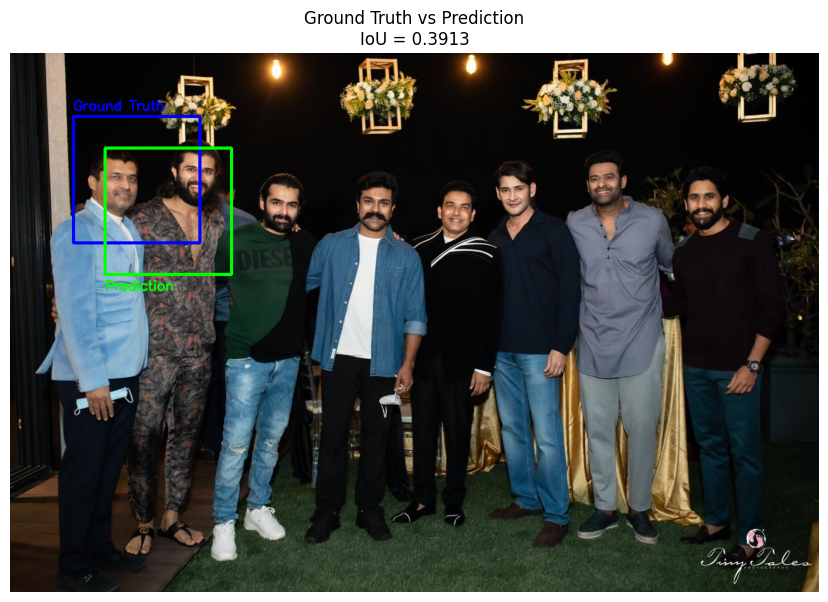


========== IoU CALCULATION ==========

Ground-Truth Box:
(100, 100) to (300, 300)

Predicted Box:
(150, 150) to (350, 350)

Ground-Truth Area: 40000
Prediction Area: 40000
Intersection Width: 150
Intersection Height: 150
Intersection Area: 22500
Union Area: 57500

IoU: 0.3913
IoU Percentage: 39.13%

========== INTERPRETATION ==========
Low to moderate overlap.


In [13]:
# ==========================================================
# CO4 - AT1 - TASK 4
# Intersection-over-Union (IoU) Calculation
# Between Predicted and Ground-Truth Bounding Boxes
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ----------------------------------------------------------
# STEP 1: Upload Image
# ----------------------------------------------------------

print("Upload an image:")

uploaded = files.upload()

filename = next(iter(uploaded))

print("Image uploaded successfully:", filename)

# ----------------------------------------------------------
# STEP 2: Read Image
# ----------------------------------------------------------

image = cv2.imread(filename)

if image is None:
    raise ValueError("Unable to read the uploaded image.")

rgb_image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

height, width = rgb_image.shape[:2]

print("\nImage dimensions:")
print("Width :", width)
print("Height:", height)

# ----------------------------------------------------------
# STEP 3: Enter Ground-Truth Bounding Box
# ----------------------------------------------------------

print("\nEnter Ground-Truth Bounding Box")
print("Format: x1, y1, x2, y2")

gt_x1 = int(input("Ground Truth x1: "))
gt_y1 = int(input("Ground Truth y1: "))
gt_x2 = int(input("Ground Truth x2: "))
gt_y2 = int(input("Ground Truth y2: "))

# ----------------------------------------------------------
# STEP 4: Enter Predicted Bounding Box
# ----------------------------------------------------------

print("\nEnter Predicted Bounding Box")
print("Format: x1, y1, x2, y2")

pred_x1 = int(input("Prediction x1: "))
pred_y1 = int(input("Prediction y1: "))
pred_x2 = int(input("Prediction x2: "))
pred_y2 = int(input("Prediction y2: "))

# ----------------------------------------------------------
# STEP 5: Calculate Intersection Coordinates
# ----------------------------------------------------------

intersection_x1 = max(
    gt_x1,
    pred_x1
)

intersection_y1 = max(
    gt_y1,
    pred_y1
)

intersection_x2 = min(
    gt_x2,
    pred_x2
)

intersection_y2 = min(
    gt_y2,
    pred_y2
)

# ----------------------------------------------------------
# STEP 6: Calculate Intersection Width and Height
# ----------------------------------------------------------

intersection_width = max(
    0,
    intersection_x2 - intersection_x1
)

intersection_height = max(
    0,
    intersection_y2 - intersection_y1
)

# ----------------------------------------------------------
# STEP 7: Calculate Intersection Area
# ----------------------------------------------------------

intersection_area = (
    intersection_width *
    intersection_height
)

# ----------------------------------------------------------
# STEP 8: Calculate Box Areas
# ----------------------------------------------------------

ground_truth_area = (
    max(0, gt_x2 - gt_x1) *
    max(0, gt_y2 - gt_y1)
)

prediction_area = (
    max(0, pred_x2 - pred_x1) *
    max(0, pred_y2 - pred_y1)
)

# ----------------------------------------------------------
# STEP 9: Calculate Union Area
# ----------------------------------------------------------

union_area = (
    ground_truth_area +
    prediction_area -
    intersection_area
)

# ----------------------------------------------------------
# STEP 10: Calculate IoU
# ----------------------------------------------------------

if union_area > 0:

    iou = (
        intersection_area /
        union_area
    )

else:

    iou = 0.0

# ----------------------------------------------------------
# STEP 11: Display Bounding Boxes
# ----------------------------------------------------------

result = rgb_image.copy()

# Ground-truth box - Blue
cv2.rectangle(
    result,
    (gt_x1, gt_y1),
    (gt_x2, gt_y2),
    (0, 0, 255),
    3
)

cv2.putText(
    result,
    "Ground Truth",
    (gt_x1, max(gt_y1 - 10, 20)),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.7,
    (0, 0, 255),
    2
)

# Predicted box - Green
cv2.rectangle(
    result,
    (pred_x1, pred_y1),
    (pred_x2, pred_y2),
    (0, 255, 0),
    3
)

cv2.putText(
    result,
    "Prediction",
    (pred_x1, min(pred_y2 + 25, height - 5)),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.7,
    (0, 255, 0),
    2
)

# ----------------------------------------------------------
# STEP 12: Display Image
# ----------------------------------------------------------

plt.figure(figsize=(12, 7))

plt.imshow(result)

plt.title(
    f"Ground Truth vs Prediction\n"
    f"IoU = {iou:.4f}"
)

plt.axis("off")

plt.show()

# ----------------------------------------------------------
# STEP 13: Display Calculations
# ----------------------------------------------------------

print("\n========== IoU CALCULATION ==========")

print("\nGround-Truth Box:")
print(
    f"({gt_x1}, {gt_y1}) "
    f"to ({gt_x2}, {gt_y2})"
)

print("\nPredicted Box:")
print(
    f"({pred_x1}, {pred_y1}) "
    f"to ({pred_x2}, {pred_y2})"
)

print("\nGround-Truth Area:",
      ground_truth_area)

print("Prediction Area:",
      prediction_area)

print("Intersection Width:",
      intersection_width)

print("Intersection Height:",
      intersection_height)

print("Intersection Area:",
      intersection_area)

print("Union Area:",
      union_area)

print("\nIoU:",
      f"{iou:.4f}")

print(
    "IoU Percentage:",
    f"{iou * 100:.2f}%"
)

# ----------------------------------------------------------
# STEP 14: Interpretation
# ----------------------------------------------------------

print("\n========== INTERPRETATION ==========")

if iou == 0:
    print("No overlap between the two bounding boxes.")

elif iou < 0.25:
    print("Very low overlap.")

elif iou < 0.50:
    print("Low to moderate overlap.")

elif iou < 0.75:
    print("Good overlap.")

else:
    print("High overlap.")

Upload a video:


Saving webcam.mp4 to webcam (1).mp4
Video uploaded successfully: webcam (1).mp4
Two consecutive frames extracted successfully.
Feature points detected: 36
Successfully tracked points: 36


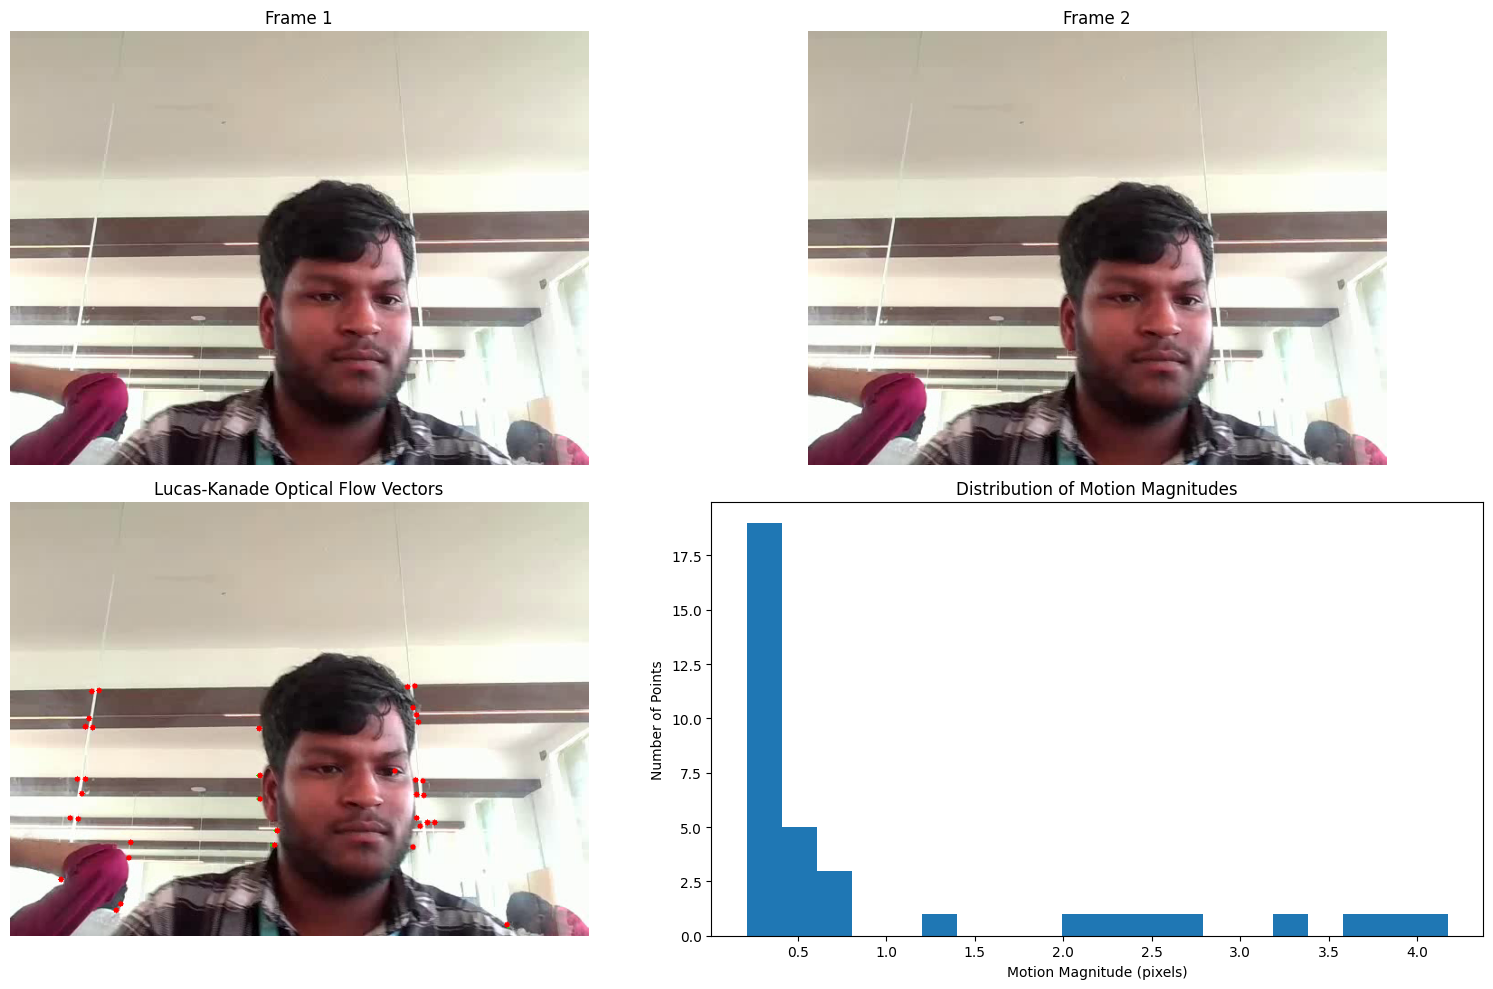


========== LUCAS-KANADE OPTICAL FLOW ==========
Frame 1 size: (480, 640)
Frame 2 size: (480, 640)
Initial feature points: 36
Successfully tracked points: 36

Average motion magnitude: 0.9902 pixels
Minimum motion magnitude: 0.2095 pixels
Maximum motion magnitude: 4.1750 pixels

Lucas-Kanade optical flow analysis completed successfully.


In [17]:
# ==========================================================
# CO4 - AT1 - TASK 5
# Analysis of Optical Flow Vectors
# Using Lucas-Kanade Method
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ----------------------------------------------------------
# STEP 1: Upload Video
# ----------------------------------------------------------

print("Upload a video:")
uploaded = files.upload()

filename = next(iter(uploaded))

print("Video uploaded successfully:", filename)

# ----------------------------------------------------------
# STEP 2: Open Video
# ----------------------------------------------------------

cap = cv2.VideoCapture(filename)

if not cap.isOpened():
    raise ValueError("Unable to open the uploaded video.")

# Read first frame
ret1, frame1 = cap.read()

# Read second consecutive frame
ret2, frame2 = cap.read()

cap.release()

if not ret1 or not ret2:
    raise ValueError(
        "Unable to read two consecutive frames."
    )

print("Two consecutive frames extracted successfully.")

# ----------------------------------------------------------
# STEP 3: Convert Frames to Grayscale
# ----------------------------------------------------------

gray1 = cv2.cvtColor(
    frame1,
    cv2.COLOR_BGR2GRAY
)

gray2 = cv2.cvtColor(
    frame2,
    cv2.COLOR_BGR2GRAY
)

# Convert frames to RGB for display
rgb1 = cv2.cvtColor(
    frame1,
    cv2.COLOR_BGR2RGB
)

rgb2 = cv2.cvtColor(
    frame2,
    cv2.COLOR_BGR2RGB
)

# ----------------------------------------------------------
# STEP 4: Detect Feature Points
# Using Shi-Tomasi Corner Detection
# ----------------------------------------------------------

feature_params = dict(
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

points1 = cv2.goodFeaturesToTrack(
    gray1,
    mask=None,
    **feature_params
)

if points1 is None:
    raise ValueError(
        "No suitable feature points were detected."
    )

print(
    "Feature points detected:",
    len(points1)
)

# ----------------------------------------------------------
# STEP 5: Lucas-Kanade Parameters
# ----------------------------------------------------------

lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(
        cv2.TERM_CRITERIA_EPS |
        cv2.TERM_CRITERIA_COUNT,
        10,
        0.03
    )
)

# ----------------------------------------------------------
# STEP 6: Calculate Optical Flow
# ----------------------------------------------------------

points2, status, error = cv2.calcOpticalFlowPyrLK(
    gray1,
    gray2,
    points1,
    None,
    **lk_params
)

if points2 is None:
    raise ValueError(
        "Lucas-Kanade optical flow could not be calculated."
    )

# ----------------------------------------------------------
# STEP 7: Select Successfully Tracked Points
# ----------------------------------------------------------

good_new = points2[
    status == 1
]

good_old = points1[
    status == 1
]

print(
    "Successfully tracked points:",
    len(good_new)
)

# ----------------------------------------------------------
# STEP 8: Calculate Motion Vectors
# ----------------------------------------------------------

motion_vectors = (
    good_new - good_old
)

# Calculate magnitude of each vector
magnitudes = np.sqrt(
    motion_vectors[:, 0] ** 2 +
    motion_vectors[:, 1] ** 2
)

# Calculate average motion
average_motion = np.mean(
    magnitudes
)

# Maximum motion
maximum_motion = np.max(
    magnitudes
)

# Minimum motion
minimum_motion = np.min(
    magnitudes
)

# ----------------------------------------------------------
# STEP 9: Draw Optical Flow Vectors
# ----------------------------------------------------------

flow_image = rgb2.copy()

for new, old in zip(
    good_new,
    good_old
):

    x_new, y_new = new.ravel()
    x_old, y_old = old.ravel()

    # Convert coordinates to integer
    x_new = int(x_new)
    y_new = int(y_new)

    x_old = int(x_old)
    y_old = int(y_old)

    # Draw motion line
    cv2.line(
        flow_image,
        (x_old, y_old),
        (x_new, y_new),
        (0, 255, 0),
        2
    )

    # Draw current point
    cv2.circle(
        flow_image,
        (x_new, y_new),
        3,
        (255, 0, 0),
        -1
    )

# ----------------------------------------------------------
# STEP 10: Display Results
# ----------------------------------------------------------

plt.figure(figsize=(16, 10))

# First frame
plt.subplot(2, 2, 1)

plt.imshow(rgb1)

plt.title(
    "Frame 1"
)

plt.axis("off")

# Second frame
plt.subplot(2, 2, 2)

plt.imshow(rgb2)

plt.title(
    "Frame 2"
)

plt.axis("off")

# Optical flow
plt.subplot(2, 2, 3)

plt.imshow(flow_image)

plt.title(
    "Lucas-Kanade Optical Flow Vectors"
)

plt.axis("off")

# Motion magnitude histogram
plt.subplot(2, 2, 4)

plt.hist(
    magnitudes,
    bins=20
)

plt.xlabel(
    "Motion Magnitude (pixels)"
)

plt.ylabel(
    "Number of Points"
)

plt.title(
    "Distribution of Motion Magnitudes"
)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# STEP 11: Display Numerical Results
# ----------------------------------------------------------

print(
    "\n========== LUCAS-KANADE OPTICAL FLOW =========="
)

print(
    "Frame 1 size:",
    gray1.shape
)

print(
    "Frame 2 size:",
    gray2.shape
)

print(
    "Initial feature points:",
    len(points1)
)

print(
    "Successfully tracked points:",
    len(good_new)
)

print(
    "\nAverage motion magnitude:",
    f"{average_motion:.4f} pixels"
)

print(
    "Minimum motion magnitude:",
    f"{minimum_motion:.4f} pixels"
)

print(
    "Maximum motion magnitude:",
    f"{maximum_motion:.4f} pixels"
)

print(
    "\nLucas-Kanade optical flow analysis completed successfully."
)

Upload a video:


Saving webcam.mp4 to webcam (2).mp4
Video uploaded successfully: webcam (2).mp4

========== VIDEO INFORMATION ==========
Width: 640
Height: 480
FPS: 1000.0
Total frames: 150


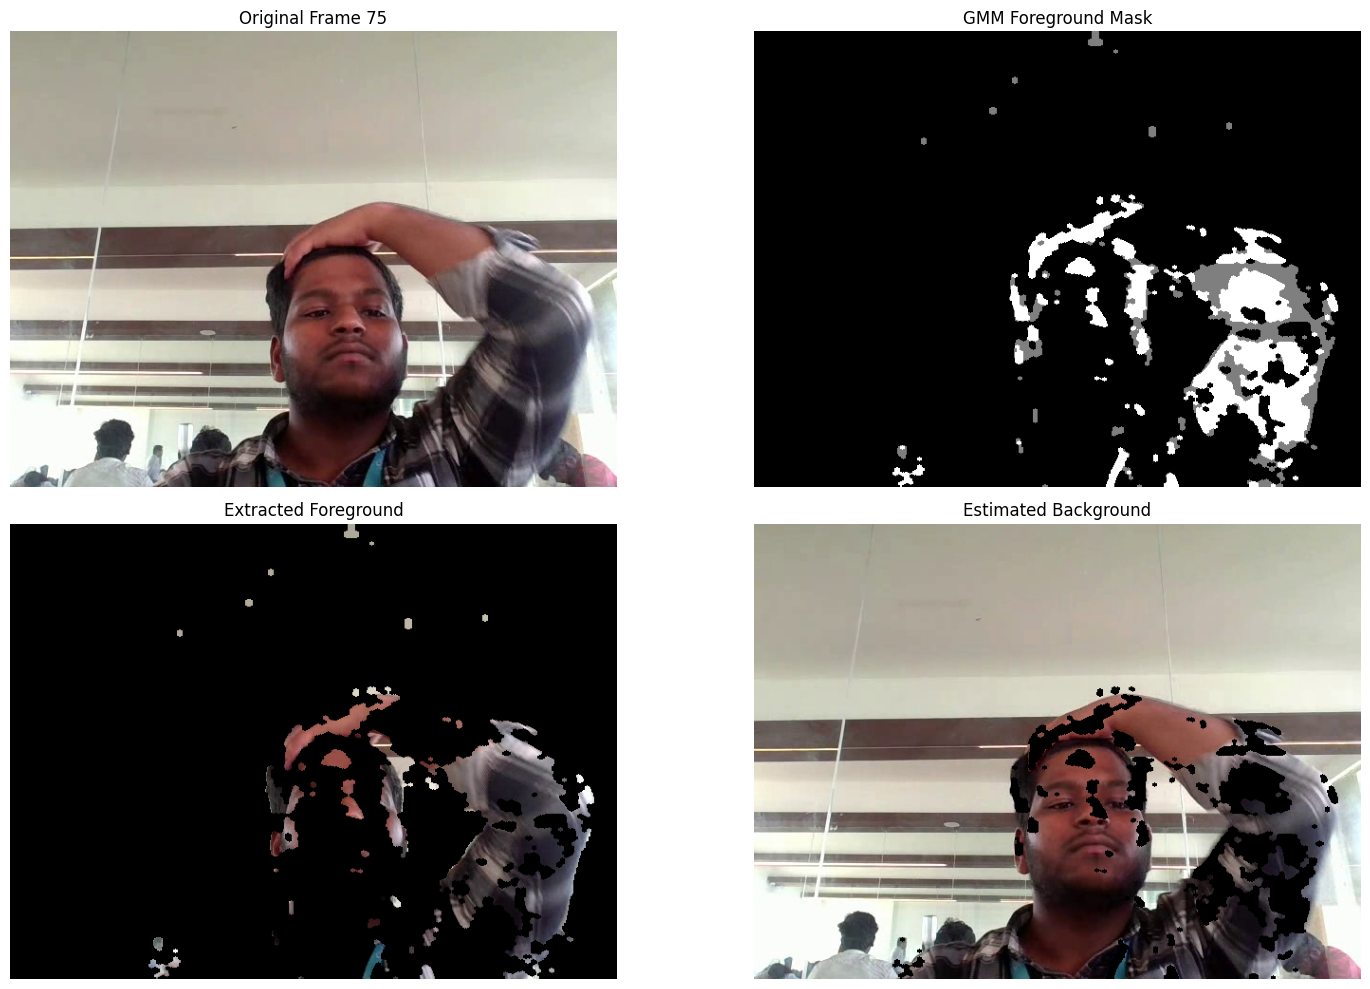


========== GMM SEGMENTATION RESULTS ==========
Frames processed: 150
Representative frame: 75
Foreground pixels: 19844
Total pixels: 307200
Foreground percentage: 6.46%

Average foreground percentage across processed frames: 6.24%

GMM background and foreground segmentation completed successfully.


In [18]:
# ==========================================================
# CO4 - AT1 - TASK 6
# Gaussian Mixture Model (GMM) for
# Background and Foreground Segmentation
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ----------------------------------------------------------
# STEP 1: Upload Video
# ----------------------------------------------------------

print("Upload a video:")

uploaded = files.upload()

filename = next(iter(uploaded))

print("Video uploaded successfully:", filename)

# ----------------------------------------------------------
# STEP 2: Open Video
# ----------------------------------------------------------

cap = cv2.VideoCapture(filename)

if not cap.isOpened():
    raise ValueError(
        "Unable to open the uploaded video."
    )

total_frames = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

fps = cap.get(
    cv2.CAP_PROP_FPS
)

width = int(
    cap.get(cv2.CAP_PROP_FRAME_WIDTH)
)

height = int(
    cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
)

print("\n========== VIDEO INFORMATION ==========")

print("Width:", width)
print("Height:", height)
print("FPS:", fps)
print("Total frames:", total_frames)

# ----------------------------------------------------------
# STEP 3: Create GMM Background Subtractor
# ----------------------------------------------------------

background_subtractor = cv2.createBackgroundSubtractorMOG2(
    history=500,
    varThreshold=16,
    detectShadows=True
)

# ----------------------------------------------------------
# STEP 4: Process Video
# ----------------------------------------------------------

representative_frame = None
representative_mask = None
representative_index = None

frame_count = 0

foreground_pixels = 0
total_pixels = 0

# Choose approximately middle frame
target_frame = max(
    1,
    total_frames // 2
)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # Apply GMM background subtraction
    fg_mask = background_subtractor.apply(
        frame
    )

    # ------------------------------------------------------
    # STEP 5: Morphological Noise Removal
    # ------------------------------------------------------

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5, 5)
    )

    cleaned_mask = cv2.morphologyEx(
        fg_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    cleaned_mask = cv2.morphologyEx(
        cleaned_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # ------------------------------------------------------
    # STEP 6: Save Representative Frame
    # ------------------------------------------------------

    if frame_count == target_frame:

        representative_frame = frame.copy()

        representative_mask = (
            cleaned_mask.copy()
        )

        representative_index = frame_count

    # ------------------------------------------------------
    # STEP 7: Calculate Foreground Percentage
    # ------------------------------------------------------

    foreground = np.sum(
        cleaned_mask == 255
    )

    pixels = cleaned_mask.size

    foreground_pixels += foreground
    total_pixels += pixels

    frame_count += 1

cap.release()

# ----------------------------------------------------------
# STEP 8: Check Processing
# ----------------------------------------------------------

if representative_frame is None:

    raise ValueError(
        "No representative frame was obtained."
    )

# ----------------------------------------------------------
# STEP 9: Convert Representative Frame to RGB
# ----------------------------------------------------------

rgb_frame = cv2.cvtColor(
    representative_frame,
    cv2.COLOR_BGR2RGB
)

# ----------------------------------------------------------
# STEP 10: Create Foreground Visualization
# ----------------------------------------------------------

foreground_result = cv2.bitwise_and(
    rgb_frame,
    rgb_frame,
    mask=representative_mask
)

# ----------------------------------------------------------
# STEP 11: Create Background Visualization
# ----------------------------------------------------------

background_result = rgb_frame.copy()

background_result[
    representative_mask == 255
] = 0

# ----------------------------------------------------------
# STEP 12: Calculate Foreground Percentage
# ----------------------------------------------------------

representative_foreground_pixels = np.sum(
    representative_mask == 255
)

representative_total_pixels = (
    representative_mask.size
)

foreground_percentage = (
    representative_foreground_pixels /
    representative_total_pixels
) * 100

# ----------------------------------------------------------
# STEP 13: Display Results
# ----------------------------------------------------------

plt.figure(figsize=(16, 10))

# Original frame
plt.subplot(2, 2, 1)

plt.imshow(rgb_frame)

plt.title(
    f"Original Frame {representative_index}"
)

plt.axis("off")

# GMM mask
plt.subplot(2, 2, 2)

plt.imshow(
    representative_mask,
    cmap="gray"
)

plt.title(
    "GMM Foreground Mask"
)

plt.axis("off")

# Foreground
plt.subplot(2, 2, 3)

plt.imshow(
    foreground_result
)

plt.title(
    "Extracted Foreground"
)

plt.axis("off")

# Background
plt.subplot(2, 2, 4)

plt.imshow(
    background_result
)

plt.title(
    "Estimated Background"
)

plt.axis("off")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# STEP 14: Display Numerical Results
# ----------------------------------------------------------

print(
    "\n========== GMM SEGMENTATION RESULTS =========="
)

print(
    "Frames processed:",
    frame_count
)

print(
    "Representative frame:",
    representative_index
)

print(
    "Foreground pixels:",
    representative_foreground_pixels
)

print(
    "Total pixels:",
    representative_total_pixels
)

print(
    "Foreground percentage:",
    f"{foreground_percentage:.2f}%"
)

print(
    "\nAverage foreground percentage "
    "across processed frames:",
    f"{(foreground_pixels / total_pixels) * 100:.2f}%"
)

print(
    "\nGMM background and foreground "
    "segmentation completed successfully."
)

Upload a video:


Saving webcam.mp4 to webcam (3).mp4
Video uploaded successfully: webcam (3).mp4

========== VIDEO INFORMATION ==========
Width: 640
Height: 480
FPS: 1000.0
Total frames: 150

Building GMM background model...
Background model created.

Evaluation frame indices: [ 30  59  89 119 149]

Evaluation frames obtained: 5

For each evaluation frame, select the approximate foreground region.
The rectangle will be used as the ground-truth foreground.

Frame 30
Suggested foreground rectangle: (356, 196, 640, 480)
Use this as a starting point and modify the coordinates if necessary.
Enter ground-truth foreground rectangle coordinates.
x1: 100
y1: 80
x2: 400
y2: 350

Frame 59
Suggested foreground rectangle: (232, 170, 640, 480)
Use this as a starting point and modify the coordinates if necessary.
Enter ground-truth foreground rectangle coordinates.
x1: 110
y1: 85
x2: 410
y2: 355

Frame 89
Suggested foreground rectangle: (266, 168, 586, 480)
Use this as a starting point and modify the coordinates if n

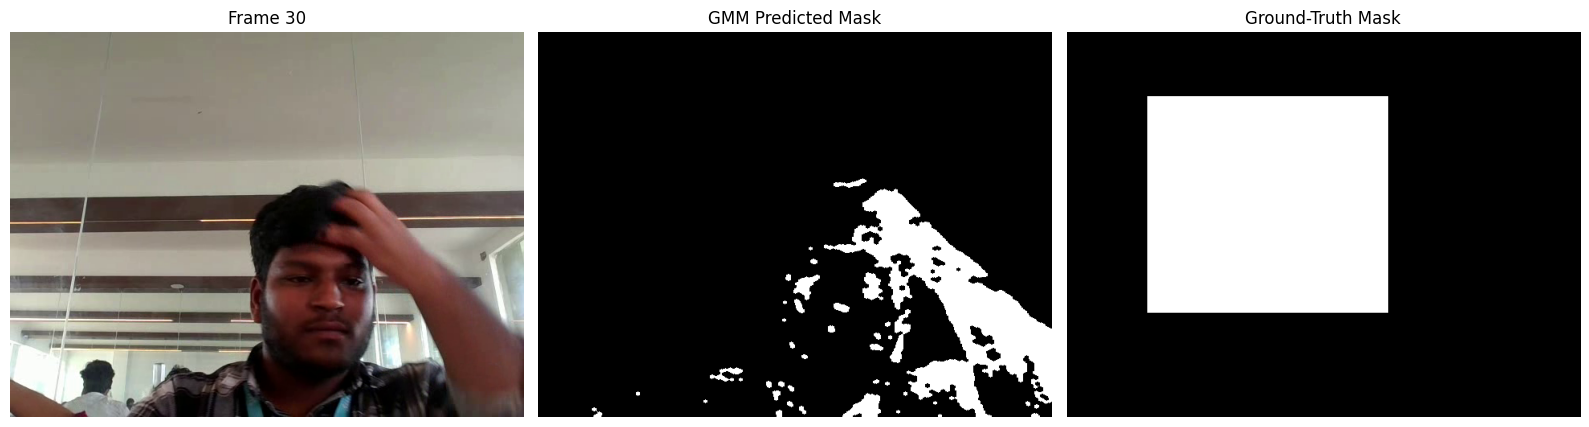

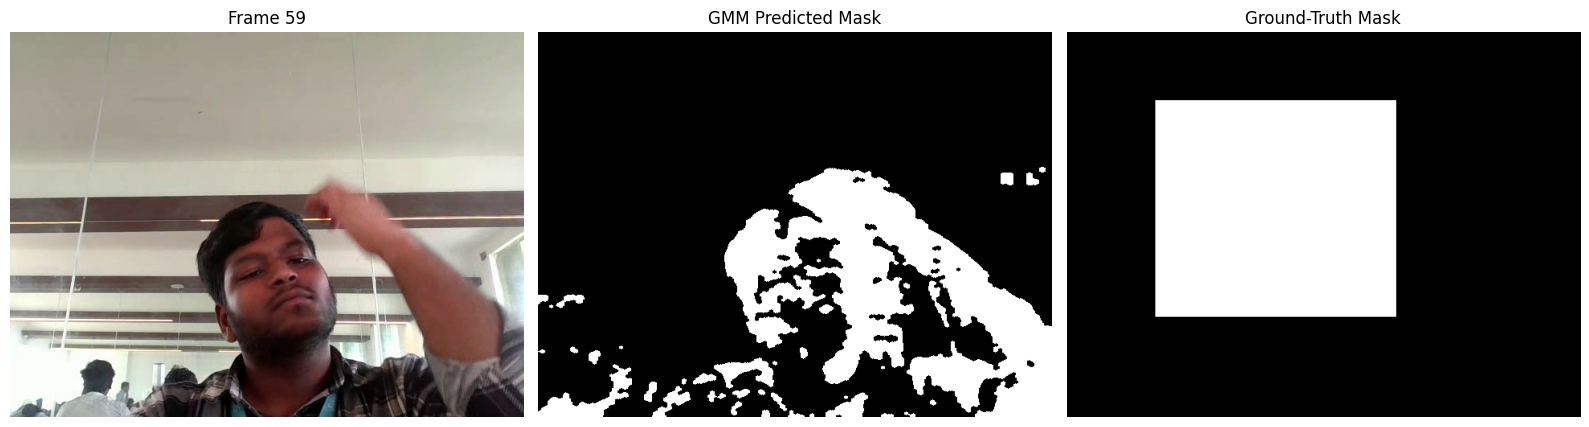

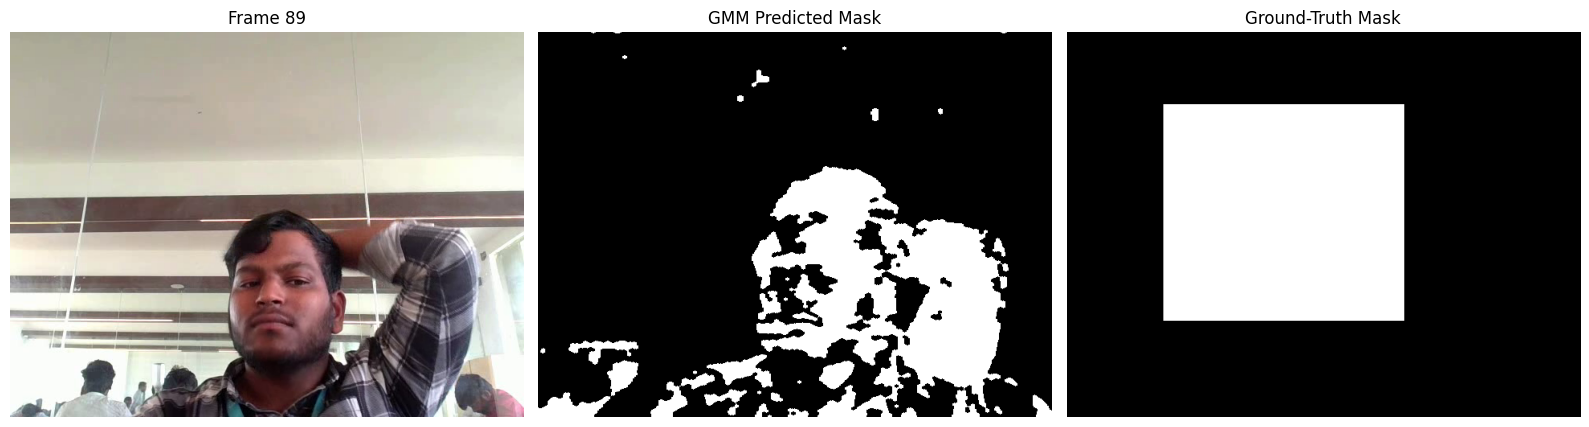

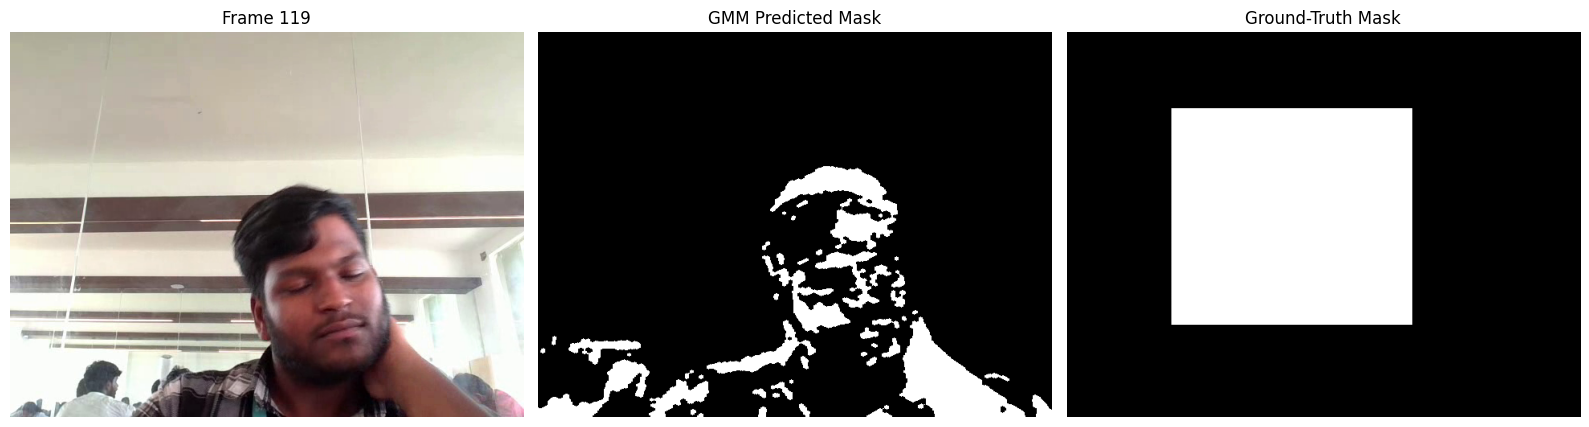

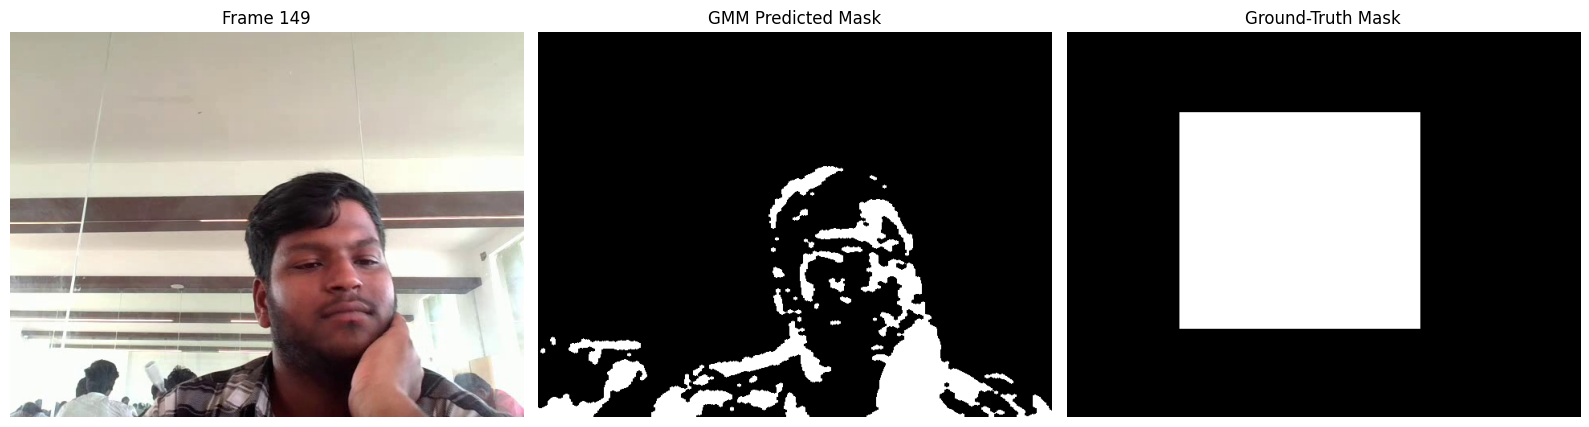


========== FRAME-WISE RESULTS ==========

Frame 30
TP: 1550
FP: 27758
FN: 79450
TN: 198442
Accuracy: 0.6510
Precision: 0.0529
Recall: 0.0191
F1-Score: 0.0281
IoU: 0.0143

Frame 59
TP: 19460
FP: 42938
FN: 61540
TN: 183262
Accuracy: 0.6599
Precision: 0.3119
Recall: 0.2402
F1-Score: 0.2714
IoU: 0.1570

Frame 89
TP: 18055
FP: 42902
FN: 62945
TN: 183298
Accuracy: 0.6554
Precision: 0.2962
Recall: 0.2229
F1-Score: 0.2544
IoU: 0.1457

Frame 119
TP: 10961
FP: 20438
FN: 70039
TN: 205762
Accuracy: 0.7055
Precision: 0.3491
Recall: 0.1353
F1-Score: 0.1950
IoU: 0.1081

Frame 149
TP: 7533
FP: 25250
FN: 73467
TN: 200950
Accuracy: 0.6787
Precision: 0.2298
Recall: 0.0930
F1-Score: 0.1324
IoU: 0.0709

========== GMM ACCURACY EVALUATION ==========
Frames evaluated: 5

Average Accuracy: 0.6701
Average Precision: 0.2480
Average Recall: 0.1421
Average F1-Score: 0.1763
Average IoU: 0.0992

Percentage Values:
Accuracy: 67.01%
Precision: 24.80%
Recall: 14.21%
F1-Score: 17.63%
IoU: 9.92%

GMM background subtrac

In [19]:
# ==========================================================
# CO4 - AT1 - TASK 7
# GMM Background Subtraction Accuracy Evaluation
# Over a Video
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ----------------------------------------------------------
# STEP 1: Upload Video
# ----------------------------------------------------------

print("Upload a video:")

uploaded = files.upload()

filename = next(iter(uploaded))

print(
    "Video uploaded successfully:",
    filename
)

# ----------------------------------------------------------
# STEP 2: Open Video
# ----------------------------------------------------------

cap = cv2.VideoCapture(filename)

if not cap.isOpened():

    raise ValueError(
        "Unable to open the uploaded video."
    )

total_frames = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

fps = cap.get(
    cv2.CAP_PROP_FPS
)

width = int(
    cap.get(cv2.CAP_PROP_FRAME_WIDTH)
)

height = int(
    cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
)

print("\n========== VIDEO INFORMATION ==========")

print("Width:", width)
print("Height:", height)
print("FPS:", fps)
print("Total frames:", total_frames)

# ----------------------------------------------------------
# STEP 3: Create GMM Background Subtractor
# ----------------------------------------------------------

gmm = cv2.createBackgroundSubtractorMOG2(
    history=500,
    varThreshold=16,
    detectShadows=False
)

# ----------------------------------------------------------
# STEP 4: Warm Up the GMM Model
# ----------------------------------------------------------

warmup_frames = min(
    30,
    max(1, total_frames // 4)
)

print(
    "\nBuilding GMM background model..."
)

for i in range(warmup_frames):

    ret, frame = cap.read()

    if not ret:
        break

    gmm.apply(frame)

print(
    "Background model created."
)

# ----------------------------------------------------------
# STEP 5: Select Evaluation Frames
# ----------------------------------------------------------

remaining_frames = (
    total_frames - warmup_frames
)

number_of_evaluation_frames = min(
    5,
    max(1, remaining_frames)
)

evaluation_indices = np.linspace(
    warmup_frames,
    total_frames - 1,
    number_of_evaluation_frames,
    dtype=int
)

print(
    "\nEvaluation frame indices:",
    evaluation_indices
)

# ----------------------------------------------------------
# STEP 6: Prepare Storage
# ----------------------------------------------------------

results = []

# ----------------------------------------------------------
# STEP 7: Process Selected Frames
# ----------------------------------------------------------

for frame_index in evaluation_indices:

    cap.set(
        cv2.CAP_PROP_POS_FRAMES,
        int(frame_index)
    )

    ret, frame = cap.read()

    if not ret:
        continue

    # Apply GMM
    mask = gmm.apply(
        frame,
        learningRate=0
    )

    # ------------------------------------------------------
    # Clean GMM Mask
    # ------------------------------------------------------

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5, 5)
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Binary mask
    predicted_mask = np.where(
        mask > 127,
        255,
        0
    ).astype(np.uint8)

    # ------------------------------------------------------
    # Store Frame and Prediction
    # ------------------------------------------------------

    results.append({
        "frame_index": frame_index,
        "frame": frame,
        "predicted_mask": predicted_mask
    })

cap.release()

# ----------------------------------------------------------
# STEP 8: Check Results
# ----------------------------------------------------------

if len(results) == 0:

    raise ValueError(
        "No evaluation frames were obtained."
    )

print(
    "\nEvaluation frames obtained:",
    len(results)
)

# ==========================================================
# STEP 9: Create Ground-Truth Masks
# ==========================================================

print(
    "\nFor each evaluation frame, "
    "select the approximate foreground region."
)

print(
    "The rectangle will be used as "
    "the ground-truth foreground."
)

evaluated_results = []

for item in results:

    frame_index = item["frame_index"]
    frame = item["frame"]
    predicted_mask = item["predicted_mask"]

    # ------------------------------------------------------
    # Create empty ground truth mask
    # ------------------------------------------------------

    ground_truth_mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    # ------------------------------------------------------
    # Automatically estimate a bounding region
    # from GMM prediction to make manual annotation easier
    # ------------------------------------------------------

    contours, _ = cv2.findContours(
        predicted_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) > 0:

        # Find largest foreground contour
        largest_contour = max(
            contours,
            key=cv2.contourArea
        )

        x, y, w, h = cv2.boundingRect(
            largest_contour
        )

        print(
            f"\nFrame {frame_index}"
        )

        print(
            "Suggested foreground rectangle:",
            (x, y, x + w, y + h)
        )

        print(
            "Use this as a starting point "
            "and modify the coordinates if necessary."
        )

        # --------------------------------------------------
        # Enter manual ground-truth coordinates
        # --------------------------------------------------

        print(
            "Enter ground-truth foreground "
            "rectangle coordinates."
        )

        gt_x1 = int(
            input("x1: ")
        )

        gt_y1 = int(
            input("y1: ")
        )

        gt_x2 = int(
            input("x2: ")
        )

        gt_y2 = int(
            input("y2: ")
        )

        # Make rectangle ground truth
        ground_truth_mask[
            gt_y1:gt_y2,
            gt_x1:gt_x2
        ] = 255

    else:

        print(
            f"No foreground contour found "
            f"for frame {frame_index}."
        )

        continue

    # ======================================================
    # STEP 10: Calculate Confusion Matrix
    # ======================================================

    predicted = (
        predicted_mask > 127
    )

    actual = (
        ground_truth_mask > 127
    )

    TP = np.sum(
        predicted & actual
    )

    FP = np.sum(
        predicted & ~actual
    )

    FN = np.sum(
        ~predicted & actual
    )

    TN = np.sum(
        ~predicted & ~actual
    )

    # ------------------------------------------------------
    # Precision
    # ------------------------------------------------------

    if TP + FP > 0:

        precision = (
            TP /
            (TP + FP)
        )

    else:

        precision = 0.0

    # ------------------------------------------------------
    # Recall
    # ------------------------------------------------------

    if TP + FN > 0:

        recall = (
            TP /
            (TP + FN)
        )

    else:

        recall = 0.0

    # ------------------------------------------------------
    # F1 Score
    # ------------------------------------------------------

    if precision + recall > 0:

        f1 = (
            2 *
            precision *
            recall /
            (precision + recall)
        )

    else:

        f1 = 0.0

    # ------------------------------------------------------
    # IoU
    # ------------------------------------------------------

    if TP + FP + FN > 0:

        iou = (
            TP /
            (TP + FP + FN)
        )

    else:

        iou = 0.0

    # ------------------------------------------------------
    # Accuracy
    # ------------------------------------------------------

    total_pixels = (
        TP + FP + FN + TN
    )

    if total_pixels > 0:

        accuracy = (
            (TP + TN) /
            total_pixels
        )

    else:

        accuracy = 0.0

    # ------------------------------------------------------
    # Store Results
    # ------------------------------------------------------

    evaluated_results.append({

        "frame_index": frame_index,

        "frame": frame,

        "predicted_mask":
            predicted_mask,

        "ground_truth_mask":
            ground_truth_mask,

        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,

        "precision":
            precision,

        "recall":
            recall,

        "f1":
            f1,

        "iou":
            iou,

        "accuracy":
            accuracy
    })

# ----------------------------------------------------------
# STEP 11: Check Evaluated Results
# ----------------------------------------------------------

if len(evaluated_results) == 0:

    raise ValueError(
        "No frames were successfully evaluated."
    )

# ==========================================================
# STEP 12: Display Frame Results
# ==========================================================

for item in evaluated_results:

    frame_index = item["frame_index"]

    frame = item["frame"]

    predicted_mask = item[
        "predicted_mask"
    ]

    ground_truth_mask = item[
        "ground_truth_mask"
    ]

    # Convert frame to RGB
    rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(16, 8))

    plt.subplot(1, 3, 1)

    plt.imshow(rgb)

    plt.title(
        f"Frame {frame_index}"
    )

    plt.axis("off")

    plt.subplot(1, 3, 2)

    plt.imshow(
        predicted_mask,
        cmap="gray"
    )

    plt.title(
        "GMM Predicted Mask"
    )

    plt.axis("off")

    plt.subplot(1, 3, 3)

    plt.imshow(
        ground_truth_mask,
        cmap="gray"
    )

    plt.title(
        "Ground-Truth Mask"
    )

    plt.axis("off")

    plt.tight_layout()

    plt.show()

# ==========================================================
# STEP 13: Display Metrics for Each Frame
# ==========================================================

print(
    "\n========== FRAME-WISE RESULTS =========="
)

for item in evaluated_results:

    print(
        f"\nFrame {item['frame_index']}"
    )

    print(
        "TP:",
        item["TP"]
    )

    print(
        "FP:",
        item["FP"]
    )

    print(
        "FN:",
        item["FN"]
    )

    print(
        "TN:",
        item["TN"]
    )

    print(
        "Accuracy:",
        f"{item['accuracy']:.4f}"
    )

    print(
        "Precision:",
        f"{item['precision']:.4f}"
    )

    print(
        "Recall:",
        f"{item['recall']:.4f}"
    )

    print(
        "F1-Score:",
        f"{item['f1']:.4f}"
    )

    print(
        "IoU:",
        f"{item['iou']:.4f}"
    )

# ==========================================================
# STEP 14: Calculate Average Metrics
# ==========================================================

avg_accuracy = np.mean([
    item["accuracy"]
    for item in evaluated_results
])

avg_precision = np.mean([
    item["precision"]
    for item in evaluated_results
])

avg_recall = np.mean([
    item["recall"]
    for item in evaluated_results
])

avg_f1 = np.mean([
    item["f1"]
    for item in evaluated_results
])

avg_iou = np.mean([
    item["iou"]
    for item in evaluated_results
])

# ----------------------------------------------------------
# STEP 15: Final Results
# ----------------------------------------------------------

print(
    "\n========== GMM ACCURACY EVALUATION =========="
)

print(
    "Frames evaluated:",
    len(evaluated_results)
)

print(
    "\nAverage Accuracy:",
    f"{avg_accuracy:.4f}"
)

print(
    "Average Precision:",
    f"{avg_precision:.4f}"
)

print(
    "Average Recall:",
    f"{avg_recall:.4f}"
)

print(
    "Average F1-Score:",
    f"{avg_f1:.4f}"
)

print(
    "Average IoU:",
    f"{avg_iou:.4f}"
)

print(
    "\nPercentage Values:"
)

print(
    "Accuracy:",
    f"{avg_accuracy * 100:.2f}%"
)

print(
    "Precision:",
    f"{avg_precision * 100:.2f}%"
)

print(
    "Recall:",
    f"{avg_recall * 100:.2f}%"
)

print(
    "F1-Score:",
    f"{avg_f1 * 100:.2f}%"
)

print(
    "IoU:",
    f"{avg_iou * 100:.2f}%"
)

print(
    "\nGMM background subtraction "
    "accuracy evaluation completed successfully."
)

Upload a video:


Saving webcam.mp4 to webcam (6).mp4
Video uploaded successfully: webcam (6).mp4

========== VIDEO INFORMATION ==========
Width: 640
Height: 480
FPS: 1000.0
Total frames: 150

Selected consecutive frames: 0 and 1
Initial feature points: 300
Successfully tracked points: 299


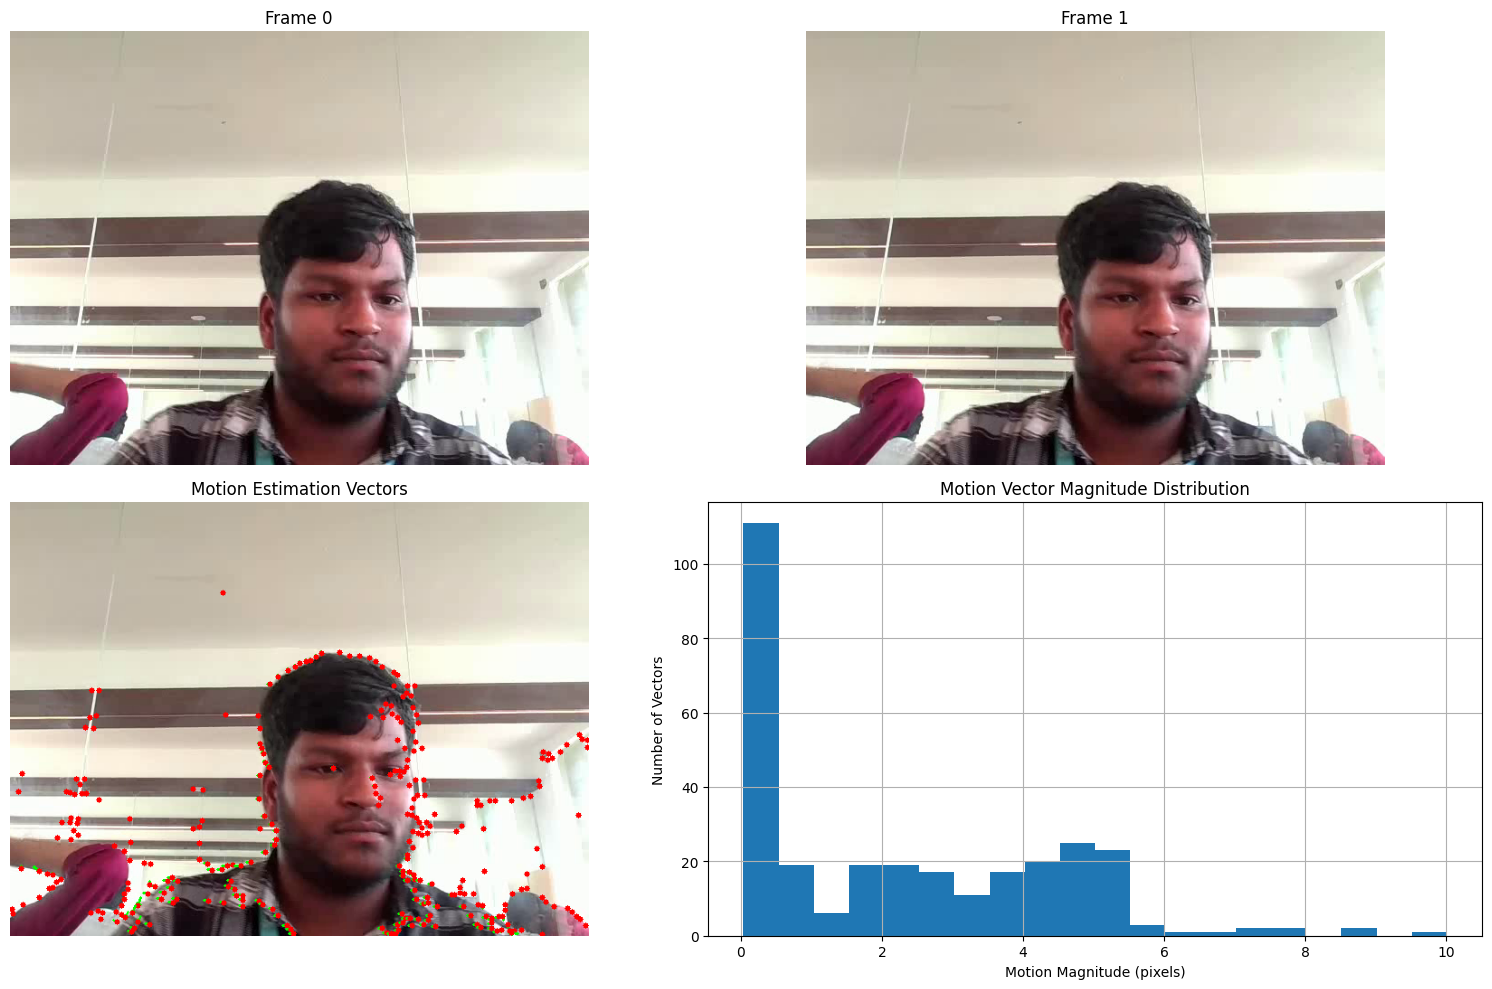


========== MOTION ESTIMATION RESULTS ==========
Frame pair: 0 → 1
Initial feature points: 300
Tracked points: 299

Average horizontal displacement (dx): 1.7836 pixels
Average vertical displacement (dy): 0.6887 pixels
Average motion magnitude: 2.3097 pixels
Median motion magnitude: 1.9528 pixels
Minimum motion magnitude: 0.0330 pixels
Maximum motion magnitude: 10.0134 pixels
Average motion direction: 21.11 degrees

Dominant motion direction: Right

Motion estimation analysis completed successfully.


In [22]:
# ==========================================================
# CO4 - AT1 - TASK 8
# Interpreting Motion Estimation Vectors
# Between Two Consecutive Frames
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ----------------------------------------------------------
# STEP 1: Upload Video
# ----------------------------------------------------------

print("Upload a video:")

uploaded = files.upload()

filename = next(iter(uploaded))

print("Video uploaded successfully:", filename)

# ----------------------------------------------------------
# STEP 2: Open Video
# ----------------------------------------------------------

cap = cv2.VideoCapture(filename)

if not cap.isOpened():
    raise ValueError("Unable to open the uploaded video.")

total_frames = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

fps = cap.get(cv2.CAP_PROP_FPS)

width = int(
    cap.get(cv2.CAP_PROP_FRAME_WIDTH)
)

height = int(
    cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
)

print("\n========== VIDEO INFORMATION ==========")
print("Width:", width)
print("Height:", height)
print("FPS:", fps)
print("Total frames:", total_frames)

# ----------------------------------------------------------
# STEP 3: Find Two Consecutive Frames with Features
# ----------------------------------------------------------

frame1 = None
frame2 = None
gray1 = None
gray2 = None
points1 = None
frame_index = None

for i in range(max(1, total_frames - 1)):

    cap.set(
        cv2.CAP_PROP_POS_FRAMES,
        i
    )

    ret1, temp_frame1 = cap.read()

    if not ret1:
        continue

    ret2, temp_frame2 = cap.read()

    if not ret2:
        continue

    # Convert to grayscale
    temp_gray1 = cv2.cvtColor(
        temp_frame1,
        cv2.COLOR_BGR2GRAY
    )

    temp_gray2 = cv2.cvtColor(
        temp_frame2,
        cv2.COLOR_BGR2GRAY
    )

    # Improve contrast
    temp_gray1 = cv2.equalizeHist(
        temp_gray1
    )

    temp_gray2 = cv2.equalizeHist(
        temp_gray2
    )

    # ------------------------------------------------------
    # Detect feature points
    # ------------------------------------------------------

    temp_points = cv2.goodFeaturesToTrack(
        temp_gray1,
        maxCorners=300,
        qualityLevel=0.01,
        minDistance=5,
        blockSize=7,
        mask=None
    )

    if (
        temp_points is not None
        and len(temp_points) >= 10
    ):

        frame1 = temp_frame1
        frame2 = temp_frame2

        gray1 = temp_gray1
        gray2 = temp_gray2

        points1 = temp_points

        frame_index = i

        break

cap.release()

# ----------------------------------------------------------
# STEP 4: Check Frames
# ----------------------------------------------------------

if frame1 is None:

    raise ValueError(
        "Could not find two consecutive frames "
        "with sufficient feature points."
    )

print(
    "\nSelected consecutive frames:",
    frame_index,
    "and",
    frame_index + 1
)

print(
    "Initial feature points:",
    len(points1)
)

# ----------------------------------------------------------
# STEP 5: Lucas-Kanade Parameters
# ----------------------------------------------------------

lk_params = dict(
    winSize=(21, 21),

    maxLevel=3,

    criteria=(
        cv2.TERM_CRITERIA_EPS |
        cv2.TERM_CRITERIA_COUNT,
        30,
        0.01
    )
)

# ----------------------------------------------------------
# STEP 6: Calculate Optical Flow
# ----------------------------------------------------------

points2, status, error = cv2.calcOpticalFlowPyrLK(
    gray1,
    gray2,
    points1,
    None,
    **lk_params
)

if points2 is None:

    raise ValueError(
        "Motion vectors could not be calculated."
    )

# ----------------------------------------------------------
# STEP 7: Keep Successfully Tracked Points
# ----------------------------------------------------------

good_old = points1[
    status.ravel() == 1
]

good_new = points2[
    status.ravel() == 1
]

if len(good_new) == 0:

    raise ValueError(
        "No points were successfully tracked."
    )

print(
    "Successfully tracked points:",
    len(good_new)
)

# ==========================================================
# STEP 8: CORRECT MOTION VECTOR CALCULATION
# ==========================================================

# Convert from (N, 1, 2) to (N, 2)
good_old = good_old.reshape(-1, 2)

good_new = good_new.reshape(-1, 2)

# Calculate displacement
vectors = good_new - good_old

# Now vectors has shape (N, 2)
dx = vectors[:, 0]

dy = vectors[:, 1]

# ----------------------------------------------------------
# STEP 9: Calculate Magnitude
# ----------------------------------------------------------

magnitude = np.sqrt(
    dx ** 2 +
    dy ** 2
)

# ----------------------------------------------------------
# STEP 10: Calculate Direction
# ----------------------------------------------------------

direction = np.degrees(
    np.arctan2(
        dy,
        dx
    )
)

# ----------------------------------------------------------
# STEP 11: Calculate Statistics
# ----------------------------------------------------------

mean_dx = np.mean(dx)

mean_dy = np.mean(dy)

mean_magnitude = np.mean(
    magnitude
)

median_magnitude = np.median(
    magnitude
)

min_magnitude = np.min(
    magnitude
)

max_magnitude = np.max(
    magnitude
)

mean_direction = np.degrees(
    np.arctan2(
        mean_dy,
        mean_dx
    )
)

# ----------------------------------------------------------
# STEP 12: Determine Dominant Direction
# ----------------------------------------------------------

if abs(mean_dx) > abs(mean_dy):

    if mean_dx > 0:
        dominant_direction = "Right"
    else:
        dominant_direction = "Left"

else:

    if mean_dy > 0:
        dominant_direction = "Down"
    else:
        dominant_direction = "Up"

# ----------------------------------------------------------
# STEP 13: Convert Frames to RGB
# ----------------------------------------------------------

rgb1 = cv2.cvtColor(
    frame1,
    cv2.COLOR_BGR2RGB
)

rgb2 = cv2.cvtColor(
    frame2,
    cv2.COLOR_BGR2RGB
)

# ----------------------------------------------------------
# STEP 14: Draw Motion Vectors
# ----------------------------------------------------------

motion_image = rgb2.copy()

for old, new in zip(
    good_old,
    good_new
):

    x1, y1 = old

    x2, y2 = new

    x1 = int(x1)
    y1 = int(y1)

    x2 = int(x2)
    y2 = int(y2)

    # Draw arrow
    cv2.arrowedLine(
        motion_image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2,
        tipLength=0.3
    )

    # Draw current point
    cv2.circle(
        motion_image,
        (x2, y2),
        3,
        (255, 0, 0),
        -1
    )

# ----------------------------------------------------------
# STEP 15: Display Results
# ----------------------------------------------------------

plt.figure(figsize=(16, 10))

# Frame 1
plt.subplot(2, 2, 1)

plt.imshow(rgb1)

plt.title(
    f"Frame {frame_index}"
)

plt.axis("off")

# Frame 2
plt.subplot(2, 2, 2)

plt.imshow(rgb2)

plt.title(
    f"Frame {frame_index + 1}"
)

plt.axis("off")

# Motion vectors
plt.subplot(2, 2, 3)

plt.imshow(motion_image)

plt.title(
    "Motion Estimation Vectors"
)

plt.axis("off")

# Magnitude histogram
plt.subplot(2, 2, 4)

plt.hist(
    magnitude,
    bins=20
)

plt.xlabel(
    "Motion Magnitude (pixels)"
)

plt.ylabel(
    "Number of Vectors"
)

plt.title(
    "Motion Vector Magnitude Distribution"
)

plt.grid(True)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# STEP 16: Display Numerical Results
# ----------------------------------------------------------

print(
    "\n========== MOTION ESTIMATION RESULTS =========="
)

print(
    "Frame pair:",
    f"{frame_index} → {frame_index + 1}"
)

print(
    "Initial feature points:",
    len(points1)
)

print(
    "Tracked points:",
    len(good_new)
)

print(
    "\nAverage horizontal displacement (dx):",
    f"{mean_dx:.4f} pixels"
)

print(
    "Average vertical displacement (dy):",
    f"{mean_dy:.4f} pixels"
)

print(
    "Average motion magnitude:",
    f"{mean_magnitude:.4f} pixels"
)

print(
    "Median motion magnitude:",
    f"{median_magnitude:.4f} pixels"
)

print(
    "Minimum motion magnitude:",
    f"{min_magnitude:.4f} pixels"
)

print(
    "Maximum motion magnitude:",
    f"{max_magnitude:.4f} pixels"
)

print(
    "Average motion direction:",
    f"{mean_direction:.2f} degrees"
)

print(
    "\nDominant motion direction:",
    dominant_direction
)

print(
    "\nMotion estimation analysis "
    "completed successfully."
)

Camera Intrinsic Matrix:
[[        800           0         320]
 [          0         800         240]
 [          0           0           1]]

Camera Projection Matrix:
[[        800           0         320           0]
 [          0         800         240           0]
 [          0           0           1           0]]

3D Reconstructed Points:
[[          0           0           5]
 [          1           0           5]
 [          1           1           5]
 [          0           1           5]
 [        0.5         0.5           4]]

Projected Image Points:
[[        320         240]
 [        480         240]
 [        480         400]
 [        320         400]
 [        420         340]]

Observed Image Points:
[[        320         240]
 [        480         240]
 [        480         400]
 [        320         400]
 [        420         340]]

========== REPROJECTION ERROR RESULTS ==========

Point 1
Observed: [        320         240]
Projected: [        320         240]
R

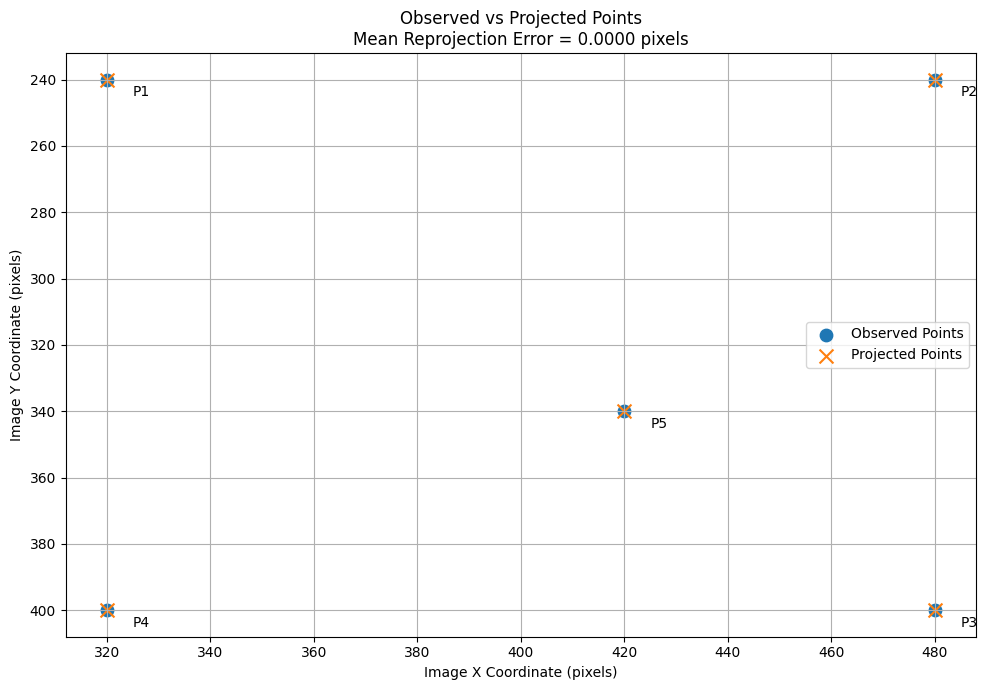


========== INTERPRETATION ==========
Very small reprojection error. The projected points closely match the observed points.

Reprojection error computation completed successfully.


In [23]:
# ==========================================================
# CO4 - AT1 - TASK 9
# Computing Reprojection Error in
# Structure-from-Motion Reconstruction
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# STEP 1: Define Camera Intrinsic Matrix
# ----------------------------------------------------------

K = np.array([
    [800,   0, 320],
    [  0, 800, 240],
    [  0,   0,   1]
], dtype=float)

print("Camera Intrinsic Matrix:")
print(K)

# ----------------------------------------------------------
# STEP 2: Define Camera Extrinsic Parameters
# ----------------------------------------------------------

# Rotation matrix
R = np.eye(3)

# Translation vector
t = np.array([
    [0],
    [0],
    [0]
], dtype=float)

# ----------------------------------------------------------
# STEP 3: Construct Camera Projection Matrix
# ----------------------------------------------------------

P = K @ np.hstack(
    (R, t)
)

print("\nCamera Projection Matrix:")
print(P)

# ----------------------------------------------------------
# STEP 4: Define Reconstructed 3D Points
# ----------------------------------------------------------

points_3D = np.array([

    [0.0, 0.0, 5.0],

    [1.0, 0.0, 5.0],

    [1.0, 1.0, 5.0],

    [0.0, 1.0, 5.0],

    [0.5, 0.5, 4.0]

], dtype=float)

print("\n3D Reconstructed Points:")
print(points_3D)

# ----------------------------------------------------------
# STEP 5: Convert 3D Points to Homogeneous Coordinates
# ----------------------------------------------------------

ones = np.ones(
    (points_3D.shape[0], 1)
)

points_3D_h = np.hstack(
    (points_3D, ones)
)

# ----------------------------------------------------------
# STEP 6: Project 3D Points onto Image Plane
# ----------------------------------------------------------

projected_h = (
    P @ points_3D_h.T
).T

# ----------------------------------------------------------
# STEP 7: Convert Homogeneous Coordinates
# ----------------------------------------------------------

projected_points = (
    projected_h[:, :2] /
    projected_h[:, 2:3]
)

print(
    "\nProjected Image Points:"
)

print(
    projected_points
)

# ----------------------------------------------------------
# STEP 8: Define Observed Image Points
# ----------------------------------------------------------

observed_points = np.array([

    [320, 240],

    [480, 240],

    [480, 400],

    [320, 400],

    [420, 340]

], dtype=float)

print(
    "\nObserved Image Points:"
)

print(
    observed_points
)

# ----------------------------------------------------------
# STEP 9: Calculate Reprojection Error
# ----------------------------------------------------------

differences = (
    observed_points -
    projected_points
)

errors = np.sqrt(
    np.sum(
        differences ** 2,
        axis=1
    )
)

# ----------------------------------------------------------
# STEP 10: Calculate Mean Reprojection Error
# ----------------------------------------------------------

mean_error = np.mean(
    errors
)

# ----------------------------------------------------------
# STEP 11: Calculate Maximum Error
# ----------------------------------------------------------

maximum_error = np.max(
    errors
)

# ----------------------------------------------------------
# STEP 12: Calculate Minimum Error
# ----------------------------------------------------------

minimum_error = np.min(
    errors
)

# ----------------------------------------------------------
# STEP 13: Display Results
# ----------------------------------------------------------

print(
    "\n========== REPROJECTION ERROR RESULTS =========="
)

for i in range(
    len(errors)
):

    print(
        f"\nPoint {i + 1}"
    )

    print(
        "Observed:",
        observed_points[i]
    )

    print(
        "Projected:",
        np.round(
            projected_points[i],
            4
        )
    )

    print(
        "Reprojection Error:",
        f"{errors[i]:.4f} pixels"
    )

print(
    "\nMean Reprojection Error:",
    f"{mean_error:.4f} pixels"
)

print(
    "Minimum Reprojection Error:",
    f"{minimum_error:.4f} pixels"
)

print(
    "Maximum Reprojection Error:",
    f"{maximum_error:.4f} pixels"
)

# ----------------------------------------------------------
# STEP 14: Visualize Observed and Projected Points
# ----------------------------------------------------------

plt.figure(
    figsize=(10, 7)
)

# Observed points
plt.scatter(
    observed_points[:, 0],
    observed_points[:, 1],
    marker="o",
    s=80,
    label="Observed Points"
)

# Projected points
plt.scatter(
    projected_points[:, 0],
    projected_points[:, 1],
    marker="x",
    s=100,
    label="Projected Points"
)

# Connect corresponding points
for i in range(
    len(observed_points)
):

    plt.plot(
        [
            observed_points[i, 0],
            projected_points[i, 0]
        ],
        [
            observed_points[i, 1],
            projected_points[i, 1]
        ],
        linestyle="--"
    )

    plt.text(
        observed_points[i, 0] + 5,
        observed_points[i, 1] + 5,
        f"P{i + 1}"
    )

plt.xlabel(
    "Image X Coordinate (pixels)"
)

plt.ylabel(
    "Image Y Coordinate (pixels)"
)

plt.title(
    f"Observed vs Projected Points\n"
    f"Mean Reprojection Error = "
    f"{mean_error:.4f} pixels"
)

plt.legend()

plt.grid(True)

# Image coordinates normally have origin at top-left
plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# STEP 15: Interpretation
# ----------------------------------------------------------

print(
    "\n========== INTERPRETATION =========="
)

if mean_error < 1:

    print(
        "Very small reprojection error. "
        "The projected points closely match "
        "the observed points."
    )

elif mean_error < 3:

    print(
        "Small reprojection error. "
        "The reconstruction provides a good "
        "image-plane fit."
    )

elif mean_error < 5:

    print(
        "Moderate reprojection error. "
        "Some difference exists between "
        "observed and projected points."
    )

else:

    print(
        "Relatively large reprojection error. "
        "The reconstruction or camera parameters "
        "may require improvement."
    )

print(
    "\nReprojection error computation "
    "completed successfully."
)

Upload a video:


Saving webcam.mp4 to webcam (7).mp4
Video uploaded successfully: webcam (7).mp4

========== VIDEO INFORMATION ==========
Width: 640
Height: 480
FPS: 1000.0
Total Frames: 150

Selected frames: 0 and 1


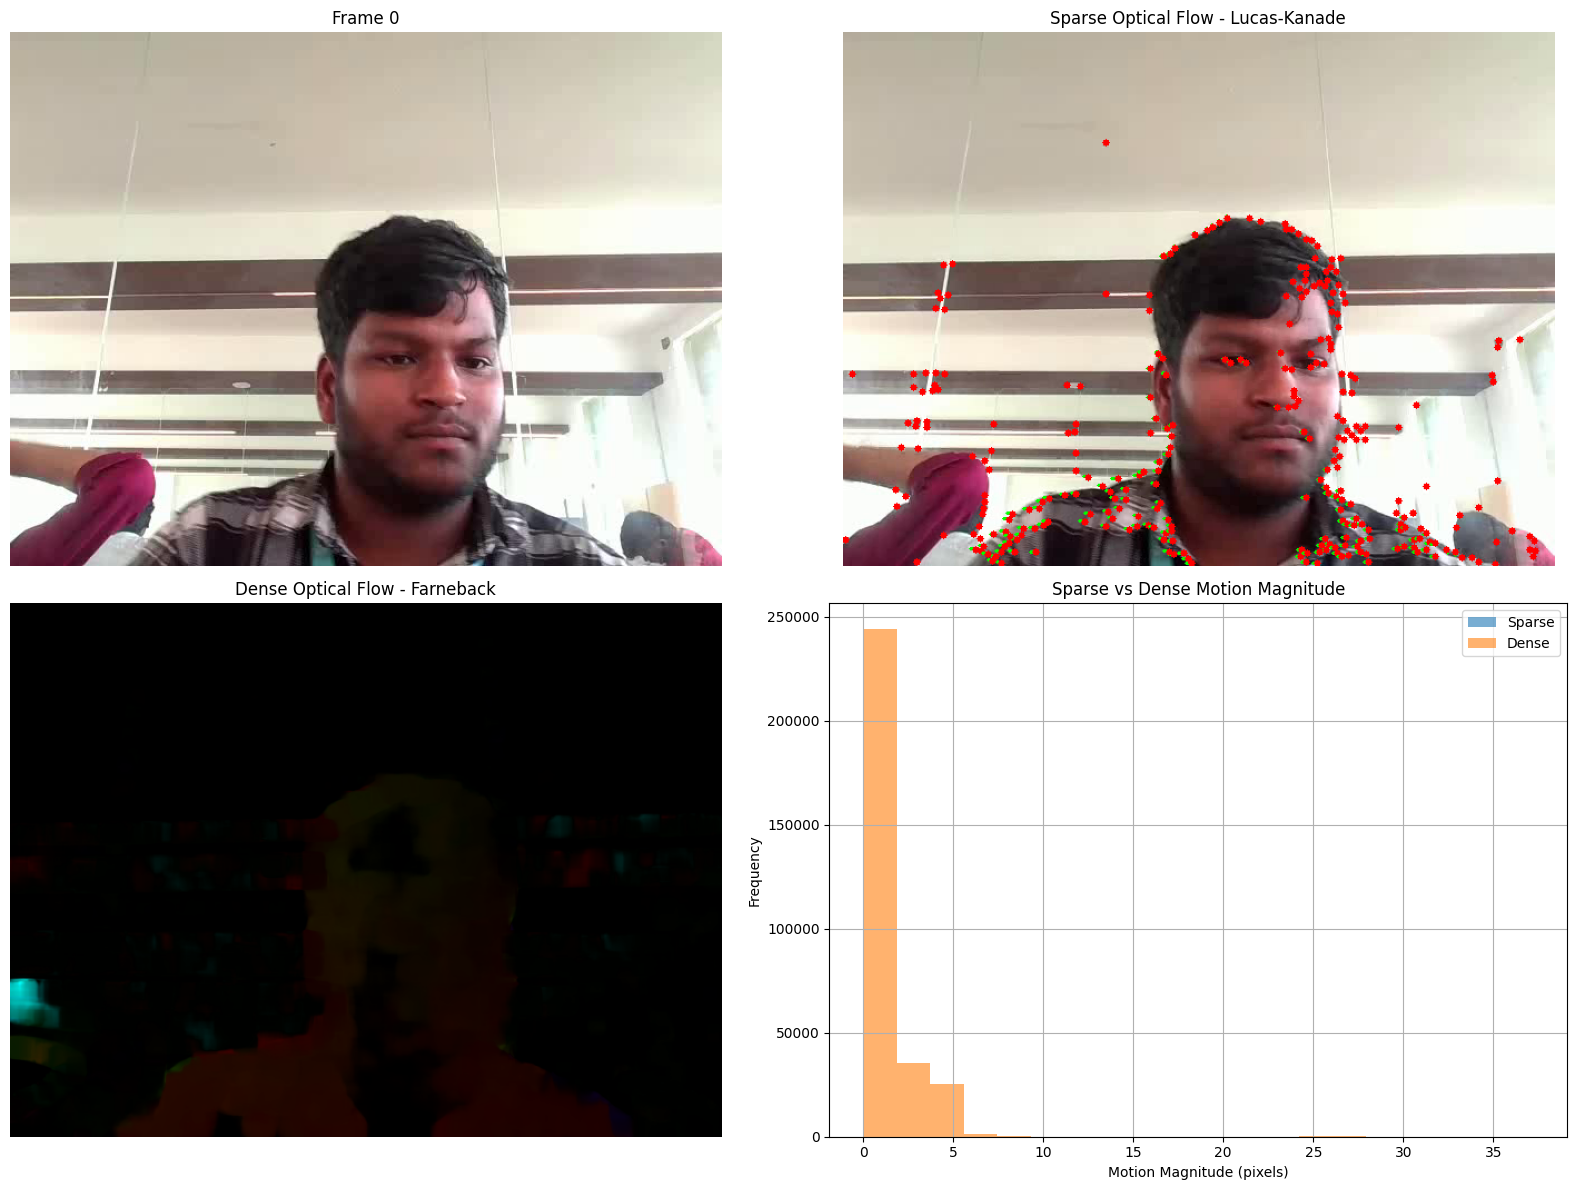


========== OPTICAL FLOW COMPARISON ==========

SPARSE OPTICAL FLOW
Method: Lucas-Kanade
Tracked feature points: 300
Average magnitude: 2.6980 pixels
Median magnitude: 2.6720 pixels
Minimum magnitude: 0.0328 pixels
Maximum magnitude: 6.5770 pixels

DENSE OPTICAL FLOW
Method: Farneback
Flow vectors: 307200
Average magnitude: 0.9631 pixels
Median magnitude: 0.1620 pixels
Minimum magnitude: 0.0000 pixels
Maximum magnitude: 37.2243 pixels

========== INTERPRETATION ==========
Sparse optical flow estimates motion only at selected feature points.
Dense optical flow estimates motion for almost every pixel in the image.

Sparse tracked points: 300
Dense flow vectors: 307200

Comparison completed successfully.


In [24]:
# ==========================================================
# CO4 - AT1 - TASK 10
# Comparing Dense vs Sparse Optical Flow
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ----------------------------------------------------------
# STEP 1: Upload Video
# ----------------------------------------------------------

print("Upload a video:")

uploaded = files.upload()

filename = next(iter(uploaded))

print(
    "Video uploaded successfully:",
    filename
)

# ----------------------------------------------------------
# STEP 2: Open Video
# ----------------------------------------------------------

cap = cv2.VideoCapture(filename)

if not cap.isOpened():

    raise ValueError(
        "Unable to open the uploaded video."
    )

total_frames = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

fps = cap.get(
    cv2.CAP_PROP_FPS
)

width = int(
    cap.get(cv2.CAP_PROP_FRAME_WIDTH)
)

height = int(
    cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
)

print("\n========== VIDEO INFORMATION ==========")

print("Width:", width)
print("Height:", height)
print("FPS:", fps)
print("Total Frames:", total_frames)

# ----------------------------------------------------------
# STEP 3: Find Two Consecutive Frames
# ----------------------------------------------------------

frame1 = None
frame2 = None
gray1 = None
gray2 = None
points1 = None
frame_index = None

for i in range(
    max(1, total_frames - 1)
):

    cap.set(
        cv2.CAP_PROP_POS_FRAMES,
        i
    )

    ret1, temp_frame1 = cap.read()

    if not ret1:
        continue

    ret2, temp_frame2 = cap.read()

    if not ret2:
        continue

    temp_gray1 = cv2.cvtColor(
        temp_frame1,
        cv2.COLOR_BGR2GRAY
    )

    temp_gray2 = cv2.cvtColor(
        temp_frame2,
        cv2.COLOR_BGR2GRAY
    )

    # ------------------------------------------------------
    # Detect feature points for sparse flow
    # ------------------------------------------------------

    temp_points = cv2.goodFeaturesToTrack(
        temp_gray1,
        maxCorners=300,
        qualityLevel=0.01,
        minDistance=5,
        blockSize=7,
        mask=None
    )

    if (
        temp_points is not None
        and len(temp_points) >= 10
    ):

        frame1 = temp_frame1
        frame2 = temp_frame2

        gray1 = temp_gray1
        gray2 = temp_gray2

        points1 = temp_points

        frame_index = i

        break

cap.release()

# ----------------------------------------------------------
# STEP 4: Check Frames
# ----------------------------------------------------------

if frame1 is None:

    raise ValueError(
        "Could not find suitable consecutive frames."
    )

print(
    "\nSelected frames:",
    frame_index,
    "and",
    frame_index + 1
)

# ==========================================================
# PART A: SPARSE OPTICAL FLOW
# ==========================================================

# ----------------------------------------------------------
# STEP 5: Lucas-Kanade Parameters
# ----------------------------------------------------------

lk_params = dict(

    winSize=(21, 21),

    maxLevel=3,

    criteria=(
        cv2.TERM_CRITERIA_EPS |
        cv2.TERM_CRITERIA_COUNT,
        30,
        0.01
    )
)

# ----------------------------------------------------------
# STEP 6: Calculate Sparse Optical Flow
# ----------------------------------------------------------

points2, status, error = cv2.calcOpticalFlowPyrLK(
    gray1,
    gray2,
    points1,
    None,
    **lk_params
)

if points2 is None:

    raise ValueError(
        "Sparse optical flow failed."
    )

# ----------------------------------------------------------
# STEP 7: Select Good Sparse Points
# ----------------------------------------------------------

good_old = points1[
    status.ravel() == 1
]

good_new = points2[
    status.ravel() == 1
]

if len(good_new) == 0:

    raise ValueError(
        "No sparse points were successfully tracked."
    )

# Reshape to (N, 2)
good_old = good_old.reshape(
    -1,
    2
)

good_new = good_new.reshape(
    -1,
    2
)

# Calculate sparse vectors
sparse_vectors = (
    good_new -
    good_old
)

sparse_dx = sparse_vectors[:, 0]

sparse_dy = sparse_vectors[:, 1]

sparse_magnitude = np.sqrt(
    sparse_dx ** 2 +
    sparse_dy ** 2
)

# ==========================================================
# PART B: DENSE OPTICAL FLOW
# ==========================================================

# ----------------------------------------------------------
# STEP 8: Calculate Farneback Dense Optical Flow
# ----------------------------------------------------------

dense_flow = cv2.calcOpticalFlowFarneback(

    gray1,
    gray2,
    None,

    pyr_scale=0.5,

    levels=3,

    winsize=15,

    iterations=3,

    poly_n=5,

    poly_sigma=1.2,

    flags=0
)

# ----------------------------------------------------------
# STEP 9: Extract Dense Flow Components
# ----------------------------------------------------------

dense_dx = dense_flow[:, :, 0]

dense_dy = dense_flow[:, :, 1]

dense_magnitude = np.sqrt(
    dense_dx ** 2 +
    dense_dy ** 2
)

dense_angle = np.arctan2(
    dense_dy,
    dense_dx
)

# ==========================================================
# PART C: VISUALIZATION
# ==========================================================

# ----------------------------------------------------------
# STEP 10: Convert Frames to RGB
# ----------------------------------------------------------

rgb1 = cv2.cvtColor(
    frame1,
    cv2.COLOR_BGR2RGB
)

rgb2 = cv2.cvtColor(
    frame2,
    cv2.COLOR_BGR2RGB
)

# ----------------------------------------------------------
# STEP 11: Sparse Flow Visualization
# ----------------------------------------------------------

sparse_image = rgb2.copy()

for old, new in zip(
    good_old,
    good_new
):

    x1, y1 = old

    x2, y2 = new

    x1 = int(x1)
    y1 = int(y1)

    x2 = int(x2)
    y2 = int(y2)

    cv2.arrowedLine(
        sparse_image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2,
        tipLength=0.3
    )

    cv2.circle(
        sparse_image,
        (x2, y2),
        3,
        (255, 0, 0),
        -1
    )

# ----------------------------------------------------------
# STEP 12: Dense Flow Visualization
# ----------------------------------------------------------

# Convert flow to HSV representation
hsv = np.zeros_like(
    frame1
)

hsv[..., 1] = 255

mag, ang = cv2.cartToPolar(
    dense_flow[..., 0],
    dense_flow[..., 1]
)

hsv[..., 0] = (
    ang * 180 /
    np.pi / 2
).astype(
    np.uint8
)

hsv[..., 2] = cv2.normalize(
    mag,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(
    np.uint8
)

dense_visualization = cv2.cvtColor(
    hsv,
    cv2.COLOR_HSV2RGB
)

# ==========================================================
# PART D: NUMERICAL COMPARISON
# ==========================================================

# ----------------------------------------------------------
# STEP 13: Sparse Statistics
# ----------------------------------------------------------

sparse_average = np.mean(
    sparse_magnitude
)

sparse_minimum = np.min(
    sparse_magnitude
)

sparse_maximum = np.max(
    sparse_magnitude
)

sparse_median = np.median(
    sparse_magnitude
)

# ----------------------------------------------------------
# STEP 14: Dense Statistics
# ----------------------------------------------------------

dense_average = np.mean(
    dense_magnitude
)

dense_minimum = np.min(
    dense_magnitude
)

dense_maximum = np.max(
    dense_magnitude
)

dense_median = np.median(
    dense_magnitude
)

# ----------------------------------------------------------
# STEP 15: Display Results
# ----------------------------------------------------------

plt.figure(
    figsize=(16, 12)
)

# Original frame
plt.subplot(2, 2, 1)

plt.imshow(rgb1)

plt.title(
    f"Frame {frame_index}"
)

plt.axis("off")

# Sparse flow
plt.subplot(2, 2, 2)

plt.imshow(sparse_image)

plt.title(
    "Sparse Optical Flow - Lucas-Kanade"
)

plt.axis("off")

# Dense flow
plt.subplot(2, 2, 3)

plt.imshow(dense_visualization)

plt.title(
    "Dense Optical Flow - Farneback"
)

plt.axis("off")

# Magnitude comparison
plt.subplot(2, 2, 4)

plt.hist(
    sparse_magnitude,
    bins=20,
    alpha=0.6,
    label="Sparse"
)

plt.hist(
    dense_magnitude.flatten(),
    bins=20,
    alpha=0.6,
    label="Dense"
)

plt.xlabel(
    "Motion Magnitude (pixels)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Sparse vs Dense Motion Magnitude"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# ==========================================================
# STEP 16: Print Numerical Results
# ==========================================================

print(
    "\n========== OPTICAL FLOW COMPARISON =========="
)

print(
    "\nSPARSE OPTICAL FLOW"
)

print(
    "Method: Lucas-Kanade"
)

print(
    "Tracked feature points:",
    len(good_new)
)

print(
    "Average magnitude:",
    f"{sparse_average:.4f} pixels"
)

print(
    "Median magnitude:",
    f"{sparse_median:.4f} pixels"
)

print(
    "Minimum magnitude:",
    f"{sparse_minimum:.4f} pixels"
)

print(
    "Maximum magnitude:",
    f"{sparse_maximum:.4f} pixels"
)

print(
    "\nDENSE OPTICAL FLOW"
)

print(
    "Method: Farneback"
)

print(
    "Flow vectors:",
    dense_magnitude.size
)

print(
    "Average magnitude:",
    f"{dense_average:.4f} pixels"
)

print(
    "Median magnitude:",
    f"{dense_median:.4f} pixels"
)

print(
    "Minimum magnitude:",
    f"{dense_minimum:.4f} pixels"
)

print(
    "Maximum magnitude:",
    f"{dense_maximum:.4f} pixels"
)

# ----------------------------------------------------------
# STEP 17: Interpretation
# ----------------------------------------------------------

print(
    "\n========== INTERPRETATION =========="
)

print(
    "Sparse optical flow estimates motion "
    "only at selected feature points."
)

print(
    "Dense optical flow estimates motion "
    "for almost every pixel in the image."
)

print(
    "\nSparse tracked points:",
    len(good_new)
)

print(
    "Dense flow vectors:",
    dense_magnitude.size
)

print(
    "\nComparison completed successfully."
)

Upload a face image:


Saving group.jpg to group (5).jpg
Image uploaded successfully: group (5).jpg

Enter the actual number of faces present in the image: 8

========== VIOLA-JONES ==========
Detected faces: 10
Detection time: 0.991651 seconds

========== YOLO ==========
YOLO person detections: 8
Detection time: 0.160031 seconds

NOTE:
The standard YOLO COCO model detects PERSON objects, whereas Viola-Jones detects FACES.
Therefore, a direct face-count accuracy comparison is not scientifically valid unless YOLO is replaced with a face-trained YOLO model.


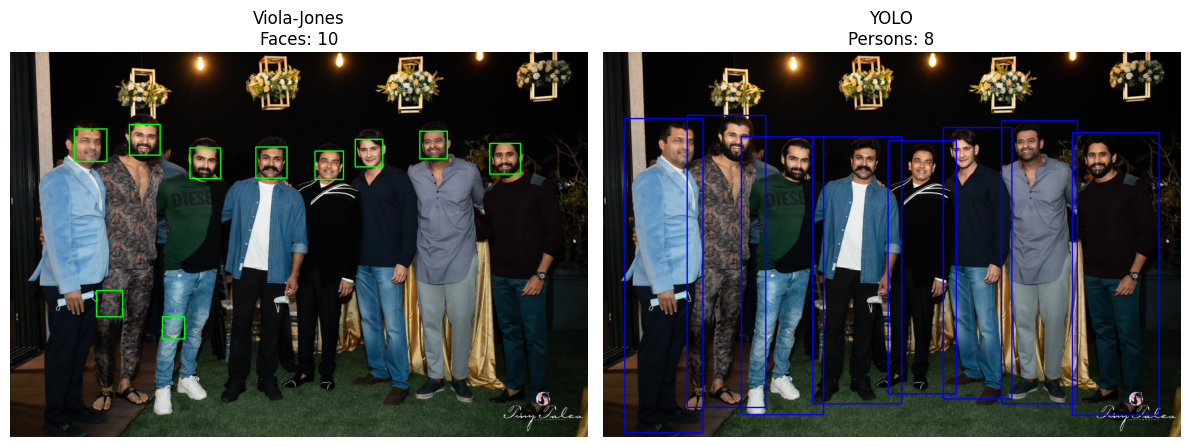


========== VIOLA-JONES RESULTS ==========
Ground truth: 8
Detected faces: 10
TP: 8
FP: 2
FN: 0
Precision: 0.8000
Recall: 1.0000
F1-Score: 0.8889
Time: 0.991651 seconds

========== YOLO RESULTS ==========
Person detections: 8
Time: 0.160031 seconds

========== SPEED COMPARISON ==========
YOLO was faster for this image.
Measured speed ratio: 6.20x

========== INTERPRETATION ==========
Viola-Jones is a classical Haar-cascade face detector and is computationally lightweight.
YOLO is a deep-learning object detector designed for general object detection.
The comparison should consider both detection speed and the type of object being detected.

Task 11 completed successfully.


In [26]:
# ==========================================================
# CO4 - AT1 - TASK 11
# Detection Speed vs Accuracy:
# Viola-Jones vs YOLO
# ==========================================================

# ----------------------------------------------------------
# STEP 1: Install Ultralytics
# ----------------------------------------------------------

!pip -q install ultralytics

# ----------------------------------------------------------
# STEP 2: Import Libraries
# ----------------------------------------------------------

import cv2
import time
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from ultralytics import YOLO

# ----------------------------------------------------------
# STEP 3: Upload Image
# ----------------------------------------------------------

print("Upload a face image:")

uploaded = files.upload()

filename = next(iter(uploaded))

print(
    "Image uploaded successfully:",
    filename
)

# ----------------------------------------------------------
# STEP 4: Read Image
# ----------------------------------------------------------

image = cv2.imread(filename)

if image is None:
    raise ValueError(
        "Unable to read the uploaded image."
    )

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

rgb_image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

# ----------------------------------------------------------
# STEP 5: Enter Ground Truth
# ----------------------------------------------------------

ground_truth = int(
    input(
        "\nEnter the actual number of faces "
        "present in the image: "
    )
)

if ground_truth < 0:
    raise ValueError(
        "Ground-truth count cannot be negative."
    )

# ==========================================================
# PART A: VIOLA-JONES
# ==========================================================

print(
    "\n========== VIOLA-JONES =========="
)

# Load Haar Cascade
cascade_path = cv2.data.haarcascades + (
    "haarcascade_frontalface_default.xml"
)

face_cascade = cv2.CascadeClassifier(
    cascade_path
)

if face_cascade.empty():
    raise ValueError(
        "Haar Cascade could not be loaded."
    )

# ----------------------------------------------------------
# STEP 6: Measure Viola-Jones Detection Time
# ----------------------------------------------------------

start_time = time.perf_counter()

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

vj_time = (
    time.perf_counter() -
    start_time
)

vj_count = len(faces)

print(
    "Detected faces:",
    vj_count
)

print(
    "Detection time:",
    f"{vj_time:.6f} seconds"
)

# ----------------------------------------------------------
# STEP 7: Calculate Viola-Jones Metrics
# ----------------------------------------------------------

# For count-based evaluation:
# TP = correctly detected faces up to ground truth
# FP = extra detections
# FN = missed faces

vj_tp = min(
    vj_count,
    ground_truth
)

vj_fp = max(
    0,
    vj_count - ground_truth
)

vj_fn = max(
    0,
    ground_truth - vj_count
)

if vj_tp + vj_fp > 0:

    vj_precision = (
        vj_tp /
        (vj_tp + vj_fp)
    )

else:

    vj_precision = 0.0

if vj_tp + vj_fn > 0:

    vj_recall = (
        vj_tp /
        (vj_tp + vj_fn)
    )

else:

    vj_recall = 0.0

if (
    vj_precision +
    vj_recall
) > 0:

    vj_f1 = (
        2 *
        vj_precision *
        vj_recall /
        (
            vj_precision +
            vj_recall
        )
    )

else:

    vj_f1 = 0.0

# ----------------------------------------------------------
# STEP 8: Draw Viola-Jones Detections
# ----------------------------------------------------------

vj_output = image.copy()

for (
    x,
    y,
    w,
    h
) in faces:

    cv2.rectangle(
        vj_output,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

# ==========================================================
# PART B: YOLO
# ==========================================================

print(
    "\n========== YOLO =========="
)

# ----------------------------------------------------------
# STEP 9: Load YOLO Model
# ----------------------------------------------------------

model = YOLO(
    "yolo11n.pt"
)

# ----------------------------------------------------------
# STEP 10: Warm-up YOLO
# ----------------------------------------------------------

# This avoids counting initial model setup time
# as the actual detection time.

model(
    image,
    verbose=False
)

# ----------------------------------------------------------
# STEP 11: Measure YOLO Detection Time
# ----------------------------------------------------------

start_time = time.perf_counter()

results = model(
    image,
    verbose=False
)

yolo_time = (
    time.perf_counter() -
    start_time
)

# ----------------------------------------------------------
# STEP 12: Extract Face Detections
# ----------------------------------------------------------

yolo_count = 0

yolo_output = image.copy()

# COCO class ID:
# person = 0
#
# Standard YOLO COCO models detect "person",
# not individual faces.
#
# Therefore, for a face-counting comparison,
# YOLO's person detections are NOT equivalent
# to face detections.

for result in results:

    boxes = result.boxes

    for box in boxes:

        cls = int(
            box.cls[0]
        )

        confidence = float(
            box.conf[0]
        )

        # Person class
        if (
            cls == 0
            and confidence >= 0.25
        ):

            yolo_count += 1

            x1, y1, x2, y2 = (
                box.xyxy[0]
                .cpu()
                .numpy()
                .astype(int)
            )

            cv2.rectangle(
                yolo_output,
                (x1, y1),
                (x2, y2),
                (255, 0, 0),
                2
            )

# ----------------------------------------------------------
# STEP 13: Display YOLO Count
# ----------------------------------------------------------

print(
    "YOLO person detections:",
    yolo_count
)

print(
    "Detection time:",
    f"{yolo_time:.6f} seconds"
)

# ==========================================================
# IMPORTANT NOTE
# ==========================================================

print(
    "\nNOTE:"
)

print(
    "The standard YOLO COCO model detects PERSON "
    "objects, whereas Viola-Jones detects FACES."
)

print(
    "Therefore, a direct face-count accuracy "
    "comparison is not scientifically valid "
    "unless YOLO is replaced with a face-trained "
    "YOLO model."
)

# ==========================================================
# PART C: DISPLAY VIOLA-JONES RESULT
# ==========================================================

plt.figure(
    figsize=(12, 5)
)

plt.subplot(
    1,
    2,
    1
)

plt.imshow(
    cv2.cvtColor(
        vj_output,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"Viola-Jones\n"
    f"Faces: {vj_count}"
)

plt.axis("off")

# ----------------------------------------------------------
# Display YOLO result
# ----------------------------------------------------------

plt.subplot(
    1,
    2,
    2
)

plt.imshow(
    cv2.cvtColor(
        yolo_output,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"YOLO\n"
    f"Persons: {yolo_count}"
)

plt.axis("off")

plt.tight_layout()

plt.show()

# ==========================================================
# PART D: RESULTS
# ==========================================================

print(
    "\n========== VIOLA-JONES RESULTS =========="
)

print(
    "Ground truth:",
    ground_truth
)

print(
    "Detected faces:",
    vj_count
)

print(
    "TP:",
    vj_tp
)

print(
    "FP:",
    vj_fp
)

print(
    "FN:",
    vj_fn
)

print(
    "Precision:",
    f"{vj_precision:.4f}"
)

print(
    "Recall:",
    f"{vj_recall:.4f}"
)

print(
    "F1-Score:",
    f"{vj_f1:.4f}"
)

print(
    "Time:",
    f"{vj_time:.6f} seconds"
)

print(
    "\n========== YOLO RESULTS =========="
)

print(
    "Person detections:",
    yolo_count
)

print(
    "Time:",
    f"{yolo_time:.6f} seconds"
)

# ==========================================================
# PART E: SPEED COMPARISON
# ==========================================================

print(
    "\n========== SPEED COMPARISON =========="
)

if vj_time < yolo_time:

    print(
        "Viola-Jones was faster for this image."
    )

elif yolo_time < vj_time:

    print(
        "YOLO was faster for this image."
    )

else:

    print(
        "Both methods had approximately "
        "the same measured time."
    )

# ----------------------------------------------------------
# Speed ratio
# ----------------------------------------------------------

if (
    vj_time > 0
    and yolo_time > 0
):

    ratio = (
        max(vj_time, yolo_time) /
        min(vj_time, yolo_time)
    )

    print(
        "Measured speed ratio:",
        f"{ratio:.2f}x"
    )

# ==========================================================
# PART F: FINAL INTERPRETATION
# ==========================================================

print(
    "\n========== INTERPRETATION =========="
)

print(
    "Viola-Jones is a classical Haar-cascade "
    "face detector and is computationally lightweight."
)

print(
    "YOLO is a deep-learning object detector "
    "designed for general object detection."
)

print(
    "The comparison should consider both "
    "detection speed and the type of object "
    "being detected."
)

print(
    "\nTask 11 completed successfully."
)

Total samples: 20
Number of classes: 4

========== CONFUSION MATRIX ==========
[[3 2 0 0]
 [1 3 0 1]
 [1 0 3 1]
 [0 1 1 3]]

Overall Accuracy: 0.6000
Accuracy Percentage: 60.00%

========== CLASS-WISE RESULTS ==========

Cat
Precision: 0.6000
Recall: 0.6000
F1-Score: 0.6000

Dog
Precision: 0.5000
Recall: 0.6000
F1-Score: 0.5455

Car
Precision: 0.7500
Recall: 0.6000
F1-Score: 0.6667

Person
Precision: 0.6000
Recall: 0.6000
F1-Score: 0.6000

========== MACRO AVERAGE ==========
Macro Precision: 0.6125
Macro Recall: 0.6000
Macro F1-Score: 0.6030

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

         Cat       0.60      0.60      0.60         5
         Dog       0.50      0.60      0.55         5
         Car       0.75      0.60      0.67         5
      Person       0.60      0.60      0.60         5

    accuracy                           0.60        20
   macro avg       0.61      0.60      0.60        20
weighted avg       0.61    

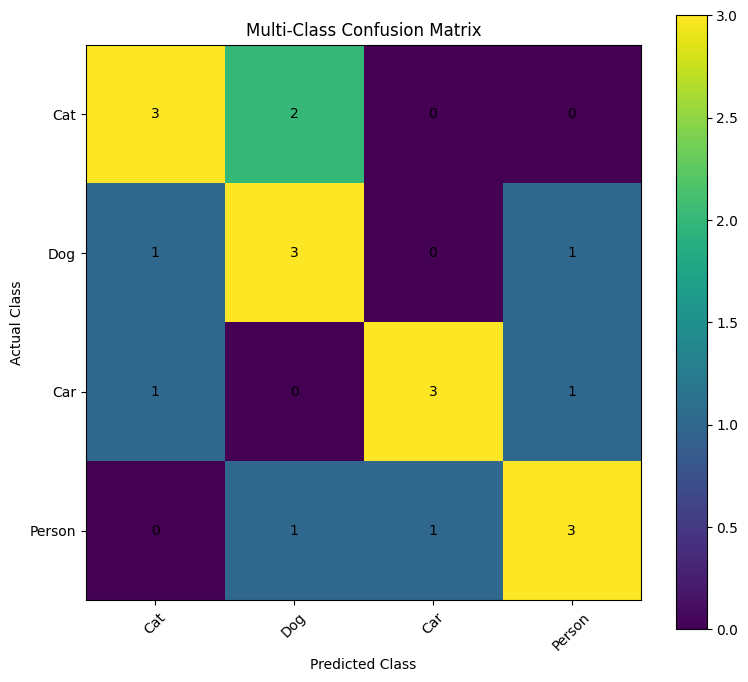


========== INTERPRETATION ==========
The diagonal elements of the confusion matrix represent correctly classified samples.
The off-diagonal elements represent misclassified samples.
A larger diagonal value indicates better recognition for that class.
The most frequent off-diagonal value identifies the strongest class confusion.

========== RESULT ==========
Multi-class confusion matrix analysis completed successfully.


In [27]:
# ==========================================================
# CO4 - AT1 - TASK 12
# Interpreting Confusion Matrix Results for a
# Multi-Class Object Recognition Model
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report
)

# ----------------------------------------------------------
# STEP 1: Define Classes
# ----------------------------------------------------------

classes = [
    "Cat",
    "Dog",
    "Car",
    "Person"
]

# ----------------------------------------------------------
# STEP 2: Actual Ground-Truth Labels
# ----------------------------------------------------------

actual = [
    "Cat",
    "Cat",
    "Cat",
    "Cat",
    "Cat",

    "Dog",
    "Dog",
    "Dog",
    "Dog",
    "Dog",

    "Car",
    "Car",
    "Car",
    "Car",
    "Car",

    "Person",
    "Person",
    "Person",
    "Person",
    "Person"
]

# ----------------------------------------------------------
# STEP 3: Predicted Labels
# ----------------------------------------------------------

predicted = [
    "Cat",
    "Cat",
    "Dog",
    "Cat",
    "Dog",

    "Dog",
    "Dog",
    "Cat",
    "Dog",
    "Person",

    "Car",
    "Car",
    "Person",
    "Car",
    "Cat",

    "Person",
    "Person",
    "Dog",
    "Person",
    "Car"
]

# ----------------------------------------------------------
# STEP 4: Check Dataset Size
# ----------------------------------------------------------

if len(actual) != len(predicted):

    raise ValueError(
        "Actual and predicted labels "
        "must have the same length."
    )

print(
    "Total samples:",
    len(actual)
)

print(
    "Number of classes:",
    len(classes)
)

# ----------------------------------------------------------
# STEP 5: Generate Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(
    actual,
    predicted,
    labels=classes
)

print(
    "\n========== CONFUSION MATRIX =========="
)

print(cm)

# ----------------------------------------------------------
# STEP 6: Calculate Overall Accuracy
# ----------------------------------------------------------

accuracy = accuracy_score(
    actual,
    predicted
)

print(
    "\nOverall Accuracy:",
    f"{accuracy:.4f}"
)

print(
    "Accuracy Percentage:",
    f"{accuracy * 100:.2f}%"
)

# ----------------------------------------------------------
# STEP 7: Calculate Precision
# ----------------------------------------------------------

precision = precision_score(
    actual,
    predicted,
    labels=classes,
    average=None,
    zero_division=0
)

# ----------------------------------------------------------
# STEP 8: Calculate Recall
# ----------------------------------------------------------

recall = recall_score(
    actual,
    predicted,
    labels=classes,
    average=None,
    zero_division=0
)

# ----------------------------------------------------------
# STEP 9: Calculate F1-Score
# ----------------------------------------------------------

f1 = f1_score(
    actual,
    predicted,
    labels=classes,
    average=None,
    zero_division=0
)

# ----------------------------------------------------------
# STEP 10: Print Class-Wise Metrics
# ----------------------------------------------------------

print(
    "\n========== CLASS-WISE RESULTS =========="
)

for i, class_name in enumerate(classes):

    print(
        f"\n{class_name}"
    )

    print(
        "Precision:",
        f"{precision[i]:.4f}"
    )

    print(
        "Recall:",
        f"{recall[i]:.4f}"
    )

    print(
        "F1-Score:",
        f"{f1[i]:.4f}"
    )

# ----------------------------------------------------------
# STEP 11: Macro-Average Metrics
# ----------------------------------------------------------

macro_precision = precision_score(
    actual,
    predicted,
    labels=classes,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    actual,
    predicted,
    labels=classes,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    actual,
    predicted,
    labels=classes,
    average="macro",
    zero_division=0
)

print(
    "\n========== MACRO AVERAGE =========="
)

print(
    "Macro Precision:",
    f"{macro_precision:.4f}"
)

print(
    "Macro Recall:",
    f"{macro_recall:.4f}"
)

print(
    "Macro F1-Score:",
    f"{macro_f1:.4f}"
)

# ----------------------------------------------------------
# STEP 12: Classification Report
# ----------------------------------------------------------

print(
    "\n========== CLASSIFICATION REPORT =========="
)

print(
    classification_report(
        actual,
        predicted,
        labels=classes,
        zero_division=0
    )
)

# ==========================================================
# STEP 13: Extract TP, FP, FN and TN
# ==========================================================

print(
    "\n========== CONFUSION-MATRIX METRICS =========="
)

total_samples = np.sum(cm)

for i, class_name in enumerate(classes):

    TP = cm[i, i]

    FP = np.sum(
        cm[:, i]
    ) - TP

    FN = np.sum(
        cm[i, :]
    ) - TP

    TN = (
        total_samples -
        TP -
        FP -
        FN
    )

    print(
        f"\nClass: {class_name}"
    )

    print(
        "TP:",
        TP
    )

    print(
        "FP:",
        FP
    )

    print(
        "FN:",
        FN
    )

    print(
        "TN:",
        TN
    )

# ==========================================================
# STEP 14: Find Most Common Misclassification
# ==========================================================

cm_without_diagonal = cm.copy()

np.fill_diagonal(
    cm_without_diagonal,
    0
)

if np.max(cm_without_diagonal) > 0:

    max_index = np.unravel_index(
        np.argmax(
            cm_without_diagonal
        ),
        cm_without_diagonal.shape
    )

    actual_class = classes[
        max_index[0]
    ]

    predicted_class = classes[
        max_index[1]
    ]

    confusion_count = cm_without_diagonal[
        max_index
    ]

    print(
        "\n========== MOST COMMON CONFUSION =========="
    )

    print(
        "Actual class:",
        actual_class
    )

    print(
        "Predicted class:",
        predicted_class
    )

    print(
        "Number of misclassifications:",
        confusion_count
    )

else:

    print(
        "\nNo misclassifications found."
    )

# ==========================================================
# STEP 15: Display Confusion Matrix
# ==========================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Multi-Class Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    np.arange(len(classes)),
    classes,
    rotation=45
)

plt.yticks(
    np.arange(len(classes)),
    classes
)

# Display values inside cells
for i in range(
    len(classes)
):

    for j in range(
        len(classes)
    ):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()

# ==========================================================
# STEP 16: Interpretation
# ==========================================================

print(
    "\n========== INTERPRETATION =========="
)

print(
    "The diagonal elements of the confusion matrix "
    "represent correctly classified samples."
)

print(
    "The off-diagonal elements represent "
    "misclassified samples."
)

print(
    "A larger diagonal value indicates better "
    "recognition for that class."
)

print(
    "The most frequent off-diagonal value identifies "
    "the strongest class confusion."
)

# ----------------------------------------------------------
# Final result
# ----------------------------------------------------------

print(
    "\n========== RESULT =========="
)

print(
    "Multi-class confusion matrix analysis "
    "completed successfully."
)